# 04 - B-spline test between polar maps and ISOMAP

This notebook tests a possible intermediate representation for scar shape:

`3D scar mesh -> continuous polar coordinates -> binary polar footprint -> closed periodic B-spline`

The goal is to check whether a smooth contour in polar space is more informative than the raw bullseye occupancy map, while staying simpler and easier to interpret than ISOMAP.

## What this notebook does

1. Reuses the same long-axis and theta-reference logic from `01_scar_exploration.ipynb`.
2. Projects the core-zone scar mesh to continuous polar coordinates `(theta, s)`.
3. Splits the scar mesh into connected fragments using the same helper rule as `01_scar_exploration.ipynb`.
4. Projects each kept fragment to polar space and fits one closed periodic B-spline per fragment.
5. Shows the original bullseye mask, the rolled rectangular fitting mask, and the unrolled splines back on the bullseye.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from scipy.interpolate import splprep, splev
from scipy.ndimage import binary_erosion, binary_fill_holes, label
from scipy.spatial import cKDTree

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data_loading import scan

HD_ROOT = r"F:/RM_TEKNON_DEVELOP"
RESULTS = ROOT / "results"
OUT = RESULTS / "04_bspline_polar_test"
OUT.mkdir(parents=True, exist_ok=True)

N_R = 64
N_THETA = 128
BOUNDARY_MIN_POINTS = 20
MIN_VERTS_FRAGMENT = 30
MAX_PLOT_FRAGMENTS = 4
KNN_CONNECT_K = 8
KNN_RADIUS_SCALE = 1.35
SPLINE_SMOOTHING = 0.002
SPLINE_SAMPLES = 400
FRAG_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

pv.set_jupyter_backend("static")
plt.rcParams["figure.dpi"] = 120

print("Notebook configured.")

Notebook configured.


In [2]:
cases = scan(HD_ROOT)

split_path_candidates = [
    RESULTS / "split.json",
    RESULTS / "01_scar_exploration" / "split.json",
]
split = None
for path in split_path_candidates:
    if path.exists():
        split = json.loads(path.read_text(encoding="utf-8"))
        break

case_by_key = {f"{case.year}/{case.patient_id}": case for case in cases}

if split is not None:
    known_keys = [key for key in split.get("known", []) if key in case_by_key]
    known = [case_by_key[key] for key in known_keys]
else:
    known = [case for case in cases if case.tissue_surfaces.get("core") is not None]
    known_keys = [f"{case.year}/{case.patient_id}" for case in known]

print(f"Scanned cases: {len(cases)}")
print(f"Known CZ cases available here: {len(known)}")

Scanned cases: 168
Known CZ cases available here: 84


In [3]:
from src.mesh_utils import (
    best_shell as _best_shell,
    connected_fragments as _connected_fragments,
    filter_fragments as _filter_fragments,
    get_cz_mesh,
)
from src.lv_geometry import (
    prepare_polar_geometry as _prepare_polar_geometry,
    project_points_to_polar,
)


def _project_points_to_polar(points, geom):
    theta, s = project_points_to_polar(points, geom)
    return {
        "theta": theta,
        "s": s,
        "axis": geom["axis"],
        "apex": geom["apex"],
        "ref_angle": geom["ref_angle"],
    }


def project_cz_to_polar(case):
    shell = _best_shell(case)
    if shell is None:
        raise ValueError("no LV shell available")
    cz = get_cz_mesh(case)
    if cz is None:
        raise ValueError("no core-zone mesh available")
    geom = _prepare_polar_geometry(shell, cz.points)
    whole_projection = _project_points_to_polar(cz.points, geom)
    whole_projection["n_points"] = cz.n_points
    whole_projection["mesh"] = cz
    fragments_all = _connected_fragments(cz)
    fragments = _filter_fragments(fragments_all, min_points=MIN_VERTS_FRAGMENT)
    projections = []
    for idx, frag in enumerate(fragments):
        proj = _project_points_to_polar(frag.points, geom)
        proj["fragment_index"] = idx
        proj["n_points"] = frag.n_points
        proj["mesh"] = frag
        projections.append(proj)
    return {
        "whole_projection": whole_projection,
        "projections": projections,
        "raw_n_fragments": len(fragments_all),
        "kept_n_fragments": len(fragments),
        "dropped_fragments": len(fragments_all) - len(fragments),
        "shell": shell,
        "cz": cz,
        "geometry": geom,
    }


print("Projection helpers ready (shared src.mesh_utils/src.lv_geometry).")


Projection helpers ready.


In [4]:
def polar_mask(theta, s, n_r=N_R, n_theta=N_THETA):
    mask = np.zeros((n_r, n_theta), dtype=bool)
    ri = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti = np.clip((theta / (2.0 * np.pi) * n_theta).astype(int), 0, n_theta - 1)
    mask[ri, ti] = True
    return mask


def _roll_mask_for_continuity(mask):
    occupied_cols = np.flatnonzero(mask.any(axis=0))
    if len(occupied_cols) == 0:
        return mask.copy(), 0
    diffs = np.diff(np.r_[occupied_cols, occupied_cols[0] + mask.shape[1]])
    gap_idx = np.argmax(diffs)
    gap_start = occupied_cols[gap_idx]
    shift = int(mask.shape[1] // 2 - (gap_start + diffs[gap_idx] // 2))
    return np.roll(mask, shift=shift, axis=1), shift


def _draw_bin_line(mask, p0, p1):
    r0, c0 = p0
    r1, c1 = p1
    steps = int(max(abs(r1 - r0), abs(c1 - c0))) + 1
    rr = np.rint(np.linspace(r0, r1, steps)).astype(int)
    cc = np.rint(np.linspace(c0, c1, steps)).astype(int)
    rr = np.clip(rr, 0, mask.shape[0] - 1)
    cc = np.clip(cc, 0, mask.shape[1] - 1)
    mask[rr, cc] = True


def _connect_mask_for_spline(mask, k=KNN_CONNECT_K, radius_scale=KNN_RADIUS_SCALE):
    if not mask.any():
        return mask.copy()
    rows, cols = np.nonzero(mask)
    pts = np.column_stack([rows.astype(float), cols.astype(float)])
    if len(pts) <= 2:
        return binary_fill_holes(mask)

    tree = cKDTree(pts)
    k_eff = min(k + 1, len(pts))
    dists, idxs = tree.query(pts, k=k_eff)
    if k_eff == 1:
        return binary_fill_holes(mask)
    if dists.ndim == 1:
        dists = dists[:, None]
        idxs = idxs[:, None]

    neighbor_dists = dists[:, 1:]
    finite_dists = neighbor_dists[np.isfinite(neighbor_dists)]
    if finite_dists.size == 0:
        return binary_fill_holes(mask)
    max_dist = max(1.5, float(np.median(finite_dists) * radius_scale))

    connected = mask.copy()
    for i in range(len(pts)):
        for dist, j in zip(dists[i, 1:], idxs[i, 1:]):
            if not np.isfinite(dist) or dist > max_dist:
                continue
            _draw_bin_line(connected, pts[i].astype(int), pts[j].astype(int))
    connected = binary_fill_holes(connected)
    return connected


def _ordered_boundary_pixels(boundary):
    coords = [tuple(rc) for rc in np.argwhere(boundary)]
    if len(coords) < BOUNDARY_MIN_POINTS:
        raise ValueError("boundary too small for spline fitting")

    coord_set = set(coords)
    neighbors = {}
    for r, c in coords:
        ngh = []
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == 0 and dc == 0:
                    continue
                cand = (r + dr, c + dc)
                if cand in coord_set:
                    ngh.append(cand)
        neighbors[(r, c)] = ngh

    start = min(coords, key=lambda rc: (rc[1], rc[0]))
    ordered = [start]
    visited = {start}
    current = start
    previous = None

    while len(visited) < len(coords):
        candidates = [p for p in neighbors[current] if p not in visited]
        if candidates:
            if previous is None:
                next_pt = min(candidates, key=lambda rc: (rc[1], rc[0]))
            else:
                direction = np.array([current[0] - previous[0], current[1] - previous[1]], dtype=float)
                if np.linalg.norm(direction) < 1e-9:
                    direction = np.array([0.0, 1.0])
                def _score(pt):
                    step = np.array([pt[0] - current[0], pt[1] - current[1]], dtype=float)
                    return (-np.dot(direction, step), pt[1], pt[0])
                next_pt = min(candidates, key=_score)
        else:
            remaining = [p for p in coords if p not in visited]
            next_pt = min(remaining, key=lambda rc: (rc[0] - current[0])**2 + (rc[1] - current[1])**2)
        ordered.append(next_pt)
        visited.add(next_pt)
        previous, current = current, next_pt

    return np.asarray(ordered, dtype=float)


def extract_boundary_points(mask):
    filled = binary_fill_holes(mask)
    boundary = filled & ~binary_erosion(filled)
    ordered = _ordered_boundary_pixels(boundary)
    x = (ordered[:, 1] + 0.5) / mask.shape[1]
    y = (ordered[:, 0] + 0.5) / mask.shape[0]
    xy = np.column_stack([x, y])
    keep = np.ones(len(xy), dtype=bool)
    keep[1:] = np.any(np.abs(np.diff(xy, axis=0)) > 1e-9, axis=1)
    xy = xy[keep]
    if len(xy) < BOUNDARY_MIN_POINTS:
        raise ValueError("not enough unique contour samples")
    return xy


def fit_periodic_bspline(xy, smoothing=SPLINE_SMOOTHING, n_samples=SPLINE_SAMPLES):
    x = xy[:, 0]
    y = xy[:, 1]
    tck, _ = splprep([x, y], s=smoothing, per=True)
    u_new = np.linspace(0.0, 1.0, n_samples)
    x_new, y_new = splev(u_new, tck)
    return np.column_stack([x_new, y_new]), tck


def _unroll_x(x, shift_bins, n_theta):
    return (x * n_theta - shift_bins) % n_theta / n_theta


def _fit_bspline_on_mask(mask, n_theta=N_THETA):
    mask_rolled, shift = _roll_mask_for_continuity(mask)
    spline_mask_rolled = _connect_mask_for_spline(mask_rolled)
    spline_mask = np.roll(spline_mask_rolled, shift=-shift, axis=1)
    boundary_xy = extract_boundary_points(spline_mask_rolled)
    spline_xy, tck = fit_periodic_bspline(boundary_xy)
    boundary_xy_unrolled = boundary_xy.copy()
    boundary_xy_unrolled[:, 0] = _unroll_x(boundary_xy_unrolled[:, 0], shift, n_theta)
    spline_xy_unrolled = spline_xy.copy()
    spline_xy_unrolled[:, 0] = _unroll_x(spline_xy_unrolled[:, 0], shift, n_theta)
    return {
        "mask": mask,
        "mask_rolled": mask_rolled,
        "spline_mask": spline_mask,
        "spline_mask_rolled": spline_mask_rolled,
        "shift": shift,
        "boundary_xy": boundary_xy,
        "spline_xy": spline_xy,
        "boundary_xy_unrolled": boundary_xy_unrolled,
        "spline_xy_unrolled": spline_xy_unrolled,
        "tck": tck,
    }


def polar_bspline_from_projection(theta, s, n_r=N_R, n_theta=N_THETA):
    mask = polar_mask(theta, s, n_r=n_r, n_theta=n_theta)
    fit = {
        "mask": mask,
        "mask_rolled": mask,
        "fit_ok": False,
        "fit_error": None,
    }
    try:
        fit.update(_fit_bspline_on_mask(mask, n_theta=n_theta))
        fit["fit_ok"] = True
    except Exception as exc:
        fit["fit_error"] = str(exc)
    return fit


def _circular_angular_spread_deg(mask):
    occupied_cols = np.flatnonzero(mask.any(axis=0))
    if len(occupied_cols) == 0:
        return 0.0
    diffs = np.diff(np.r_[occupied_cols, occupied_cols[0] + mask.shape[1]])
    max_gap = diffs.max()
    covered = mask.shape[1] - max_gap
    return 360.0 * covered / mask.shape[1]


def bspline_fragments_from_case(case, n_r=N_R, n_theta=N_THETA):
    proj_case = project_cz_to_polar(case)
    whole_fit = polar_bspline_from_projection(
        proj_case["whole_projection"]["theta"],
        proj_case["whole_projection"]["s"],
        n_r=n_r,
        n_theta=n_theta,
    )
    whole_fit["theta"] = proj_case["whole_projection"]["theta"]
    whole_fit["s"] = proj_case["whole_projection"]["s"]
    whole_fit["n_points"] = proj_case["whole_projection"]["n_points"]
    fits = []
    for proj in proj_case["projections"]:
        fit = polar_bspline_from_projection(proj["theta"], proj["s"], n_r=n_r, n_theta=n_theta)
        fit["fragment_index"] = proj["fragment_index"]
        fit["n_points"] = proj["n_points"]
        fit["theta"] = proj["theta"]
        fit["s"] = proj["s"]
        fits.append(fit)
    mask_union = np.zeros((n_r, n_theta), dtype=bool)
    all_theta = []
    all_s = []
    for fit in fits:
        mask_union |= fit["mask"]
        all_theta.append(fit["theta"])
        all_s.append(fit["s"])
    envelope_fit = whole_fit
    vertex_counts = [proj["n_points"] for proj in proj_case["projections"]]
    total_vertices = max(sum(vertex_counts), 1)
    largest_fraction = (max(vertex_counts) / total_vertices) if vertex_counts else 0.0
    radial_spread = float(proj_case["whole_projection"]["s"].max() - proj_case["whole_projection"]["s"].min())
    angular_spread_deg = _circular_angular_spread_deg(whole_fit["mask"])
    proj_case["fits"] = fits
    proj_case["mask_union"] = mask_union
    proj_case["whole_fit"] = whole_fit
    proj_case["envelope_fit"] = envelope_fit
    proj_case["largest_fraction"] = largest_fraction
    proj_case["angular_spread_deg"] = angular_spread_deg
    proj_case["radial_spread"] = radial_spread
    return proj_case


print("Boundary and B-spline helpers ready.")

Boundary and B-spline helpers ready.


In [5]:
def _draw_bullseye_background(ax):
    theta = np.linspace(0.0, 2.0 * np.pi, 361)
    for radius in (0.25, 0.50, 0.75, 1.0):
        ax.plot(theta, np.full_like(theta, radius), color="#444444", lw=0.7, alpha=0.7)
    for deg in (30, 90, 150, 210, 270, 330):
        th = np.deg2rad(deg)
        ax.plot([th, th], [0.50, 1.0], color="#444444", lw=0.7, alpha=0.7)
    for deg in (45, 135, 225, 315):
        th = np.deg2rad(deg)
        ax.plot([th, th], [0.0, 0.50], color="#444444", lw=0.7, alpha=0.7)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rticks([])
    ax.set_xticks([])


def _plot_bullseye_mask(ax, mask, title):
    n_r, n_theta = mask.shape
    theta_edges = np.linspace(0.0, 2.0 * np.pi, n_theta + 1)
    r_edges = np.linspace(0.0, 1.0, n_r + 1)
    t_grid, r_grid = np.meshgrid(theta_edges, r_edges)
    ax.pcolormesh(t_grid, r_grid, mask.astype(float), cmap="Reds", vmin=0.0, vmax=1.0, shading="flat")
    _draw_bullseye_background(ax)
    ax.set_title(title, fontsize=9)


def _plot_bullseye_fits(ax, mask, fits, title):
    _plot_bullseye_mask(ax, mask, title)
    for idx, fit in enumerate(fits[:MAX_PLOT_FRAGMENTS]):
        if not fit.get("fit_ok", False):
            continue
        theta = fit["spline_xy_unrolled"][:, 0] * 2.0 * np.pi
        radius = fit["spline_xy_unrolled"][:, 1]
        ax.plot(theta, radius, color=FRAG_COLORS[idx % len(FRAG_COLORS)], lw=2)


def _plot_bullseye_envelope(ax, mask, envelope_fit, title):
    _plot_bullseye_mask(ax, mask, title)
    if envelope_fit.get("fit_ok", False):
        theta = envelope_fit["spline_xy_unrolled"][:, 0] * 2.0 * np.pi
        radius = envelope_fit["spline_xy_unrolled"][:, 1]
        ax.plot(theta, radius, color="black", lw=2.2)


def _render_fragments_3d(case, projections):
    shell = _best_shell(case)
    pl = pv.Plotter(off_screen=True, window_size=(420, 320))
    pl.set_background("white")
    if shell is not None:
        pl.add_mesh(shell, color="#cccccc", opacity=0.15, smooth_shading=True, show_scalar_bar=False)
    for idx, proj in enumerate(projections[:MAX_PLOT_FRAGMENTS]):
        pl.add_mesh(proj["mesh"], color=FRAG_COLORS[idx % len(FRAG_COLORS)], opacity=0.95, smooth_shading=True, show_scalar_bar=False)
    pl.view_isometric()
    pl.camera.zoom(1.25)
    image = pl.screenshot(None, return_img=True)
    pl.close()
    return image


def plot_bspline_case(case, n_r=N_R, n_theta=N_THETA, save=False):
    key = f"{case.year}/{case.patient_id}"
    result = bspline_fragments_from_case(case, n_r=n_r, n_theta=n_theta)
    projections = result["projections"]
    fits = result["fits"]
    mask_union = result["mask_union"]
    whole_fit = result["whole_fit"]
    envelope_fit = result["envelope_fit"]
    mask_union_rolled = whole_fit.get("mask_rolled", whole_fit["mask"])

    fig = plt.figure(figsize=(23, 8))
    gs = fig.add_gridspec(2, 4, width_ratios=[1.05, 1.1, 1.1, 0.85], height_ratios=[1.0, 1.0])
    fig.suptitle(f"B-spline polar test | {key}", fontsize=12)

    ax_3d = fig.add_subplot(gs[0, 0])
    ax_points = fig.add_subplot(gs[0, 1])
    ax_rect = fig.add_subplot(gs[0, 2])
    ax_table = fig.add_subplot(gs[:, 3])
    ax_bull_mask = fig.add_subplot(gs[1, 0], projection="polar")
    ax_bull_spline = fig.add_subplot(gs[1, 1], projection="polar")
    ax_bull_envelope = fig.add_subplot(gs[1, 2], projection="polar")

    ax_3d.imshow(_render_fragments_3d(case, projections))
    ax_3d.set_title(f"3D scar fragments | kept={result['kept_n_fragments']} dropped={result['dropped_fragments']}", fontsize=9)
    ax_3d.axis("off")

    for idx, fit in enumerate(fits[:MAX_PLOT_FRAGMENTS]):
        ax_points.scatter(fit["theta"] / (2.0 * np.pi), fit["s"], s=4, alpha=0.45, c=FRAG_COLORS[idx % len(FRAG_COLORS)], label=f"F{idx+1}")
    ax_points.axvline(0.0, color="#888888", lw=1, ls="--")
    ax_points.axvline(1.0, color="#888888", lw=1, ls="--")
    ax_points.set_title("Continuous polar points by fragment", fontsize=9)
    ax_points.set_xlabel("theta / 2pi")
    ax_points.set_ylabel("s (apex -> base)")
    ax_points.set_xlim(0.0, 1.0)
    ax_points.set_ylim(0.0, 1.0)
    if fits:
        ax_points.legend(fontsize=7, loc="upper right")

    ax_rect.imshow(mask_union_rolled, origin="lower", aspect="auto", cmap="Greys", alpha=0.12)
    for idx, fit in enumerate(fits[:MAX_PLOT_FRAGMENTS]):
        color = FRAG_COLORS[idx % len(FRAG_COLORS)]
        if fit.get("fit_ok", False):
            yy_conn, xx_conn = np.nonzero(fit["spline_mask_rolled"])
            if len(xx_conn):
                ax_rect.plot(xx_conn, yy_conn, ".", ms=1.1, color=color, alpha=0.18)
            ax_rect.plot(fit["boundary_xy"][:, 0] * n_theta, fit["boundary_xy"][:, 1] * n_r, ".", ms=2, color=color)
            ax_rect.plot(fit["spline_xy"][:, 0] * n_theta, fit["spline_xy"][:, 1] * n_r, color=color, lw=2)
        else:
            yy, xx = np.nonzero(fit["mask_rolled"])
            if len(xx):
                ax_rect.plot(xx, yy, ".", ms=1.5, color=color, alpha=0.7)
    if whole_fit.get("fit_ok", False):
        ax_rect.plot(whole_fit["spline_xy"][:, 0] * n_theta, whole_fit["spline_xy"][:, 1] * n_r, color="black", lw=2.2)
    shift_text = ", ".join([f"F{idx+1}:{fit.get('shift', 'na')}" for idx, fit in enumerate(fits[:MAX_PLOT_FRAGMENTS])])
    ax_rect.set_title(f"Rolled rectangular fitting mask | fragment shifts {shift_text} | knn k={KNN_CONNECT_K}, scale={KNN_RADIUS_SCALE}", fontsize=9)
    ax_rect.set_xlabel("rolled theta bins")
    ax_rect.set_ylabel("radial bins")

    _plot_bullseye_mask(ax_bull_mask, whole_fit["mask"], "Original bullseye mask (whole scar)")
    _plot_bullseye_fits(ax_bull_spline, mask_union, fits, "Individual fragment splines")
    _plot_bullseye_envelope(ax_bull_envelope, whole_fit["mask"], envelope_fit, "Outer global envelope (whole scar)")

    ax_table.axis("off")
    summary_rows = [
        ["raw fragments", result["raw_n_fragments"]],
        ["kept fragments", result["kept_n_fragments"]],
        ["dropped fragments", result["dropped_fragments"]],
        ["whole spline", int(whole_fit.get("fit_ok", False))],
        ["fragment splines", sum(1 for fit in fits if fit.get("fit_ok", False))],
        ["knn connect", f"k={KNN_CONNECT_K}, scale={KNN_RADIUS_SCALE}"],
        ["largest_fraction", f"{result['largest_fraction']:.3f}"],
        ["angular spread", f"{result['angular_spread_deg']:.1f} deg"],
        ["radial spread", f"{result['radial_spread']:.3f}"],
    ]
    table = ax_table.table(cellText=summary_rows, colLabels=["metric", "value"], loc="center", cellLoc="left")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.5)
    ax_table.set_title("Case summary", fontsize=10, pad=8)

    plt.tight_layout()
    if save:
        out_path = OUT / f"{case.year}_{case.patient_id}_bspline_test.png"
        plt.savefig(out_path, bbox_inches="tight")
        print(f"Saved {out_path}")
    plt.show()

    return result


print("Plotting helpers ready.")

Plotting helpers ready.


## Single-case test

Pick any `known_keys` entry, or leave the default if you just want a first visual check.

In [6]:
known_keys[:10]

['2024/20001226',
 '2022/11003916',
 '2021/14003849',
 '2024/50139122',
 '2023/00016504',
 '2022/50039292',
 '2022/50029831',
 '2022/18002857',
 '2025/18049097',
 '2022/10008145']

## Small batch review

This is useful for quickly checking whether the spline remains stable across several patients.
If some cases fail, that is already informative: it means the boundary extraction or the periodic contour assumption is too brittle for that type of scar footprint.

C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`,

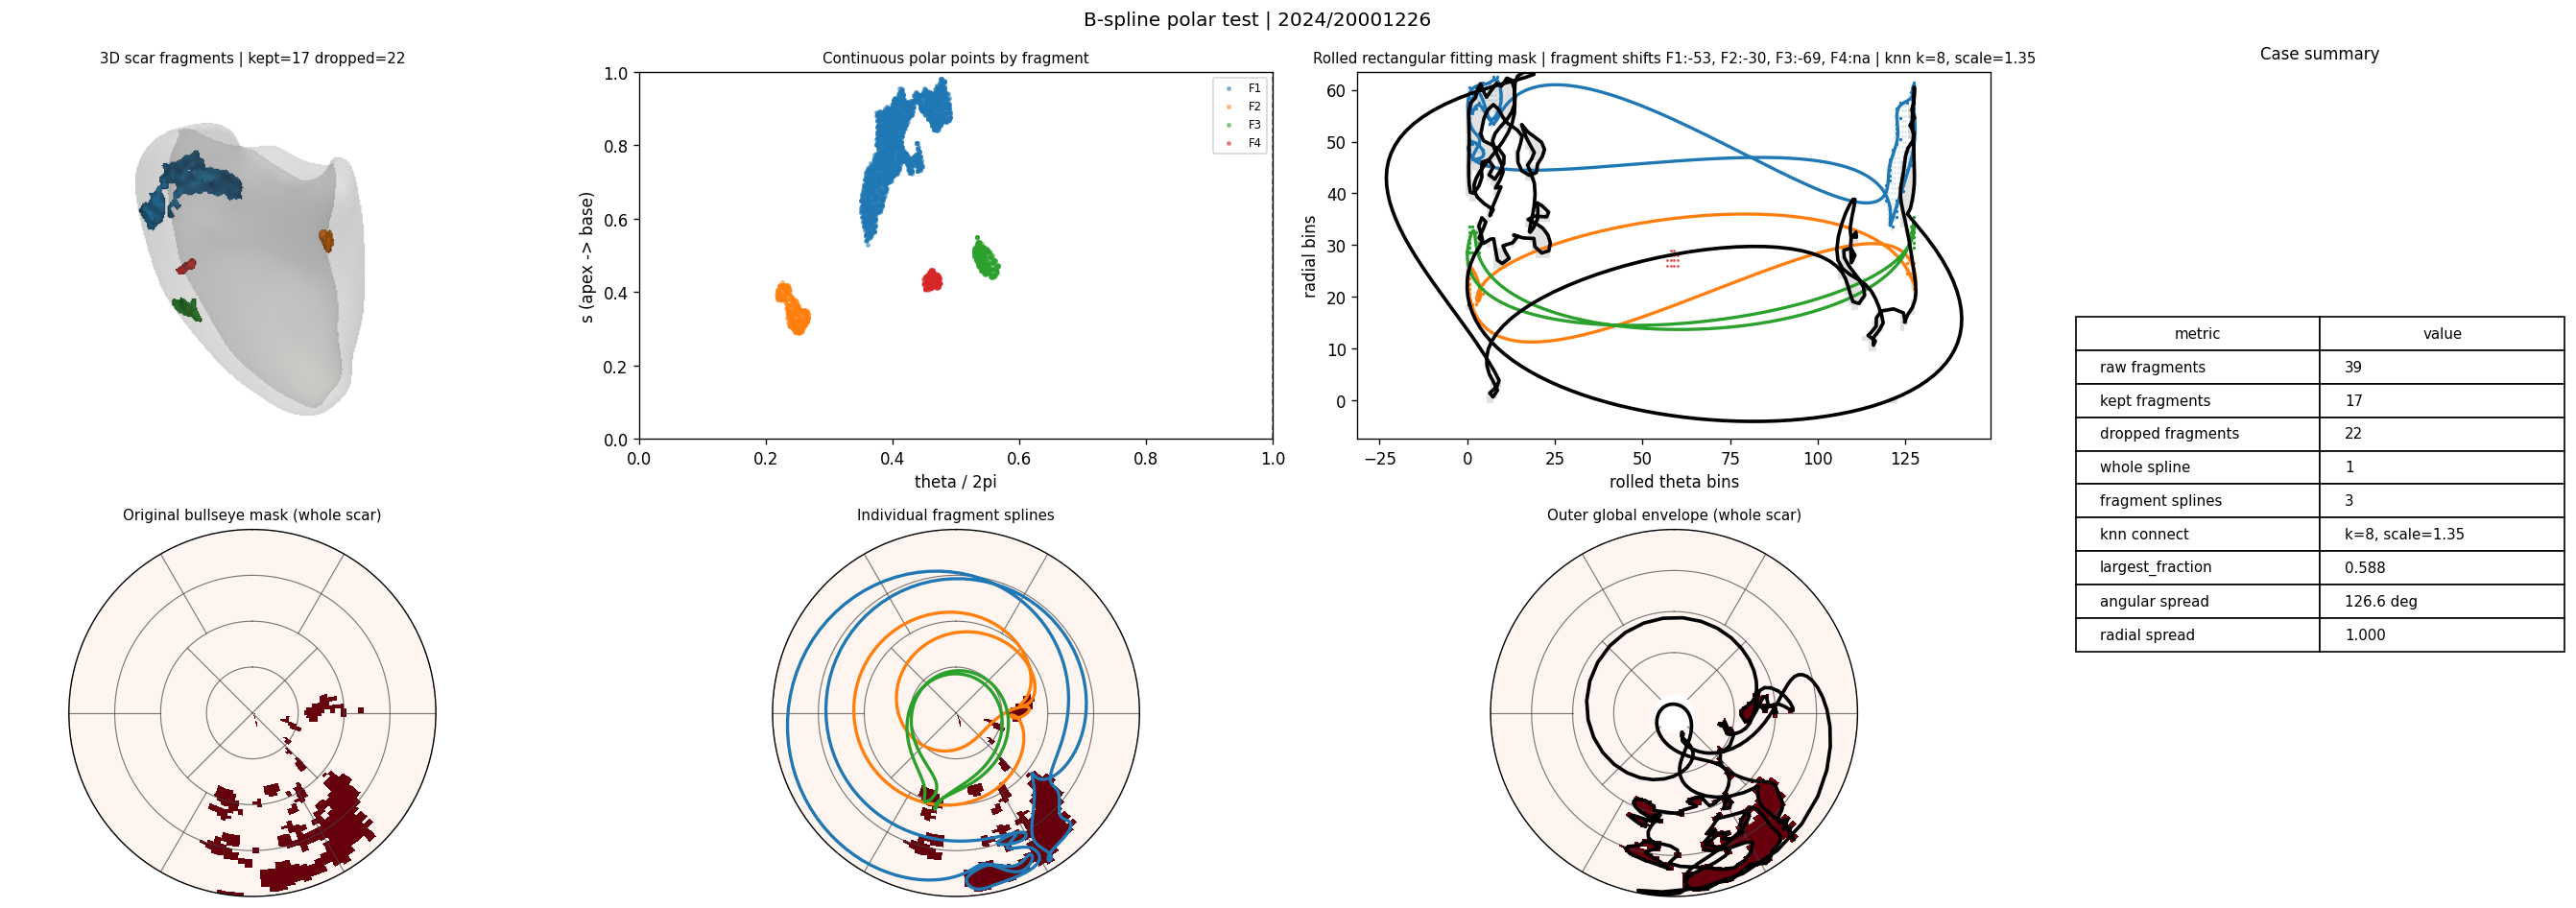

C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`,

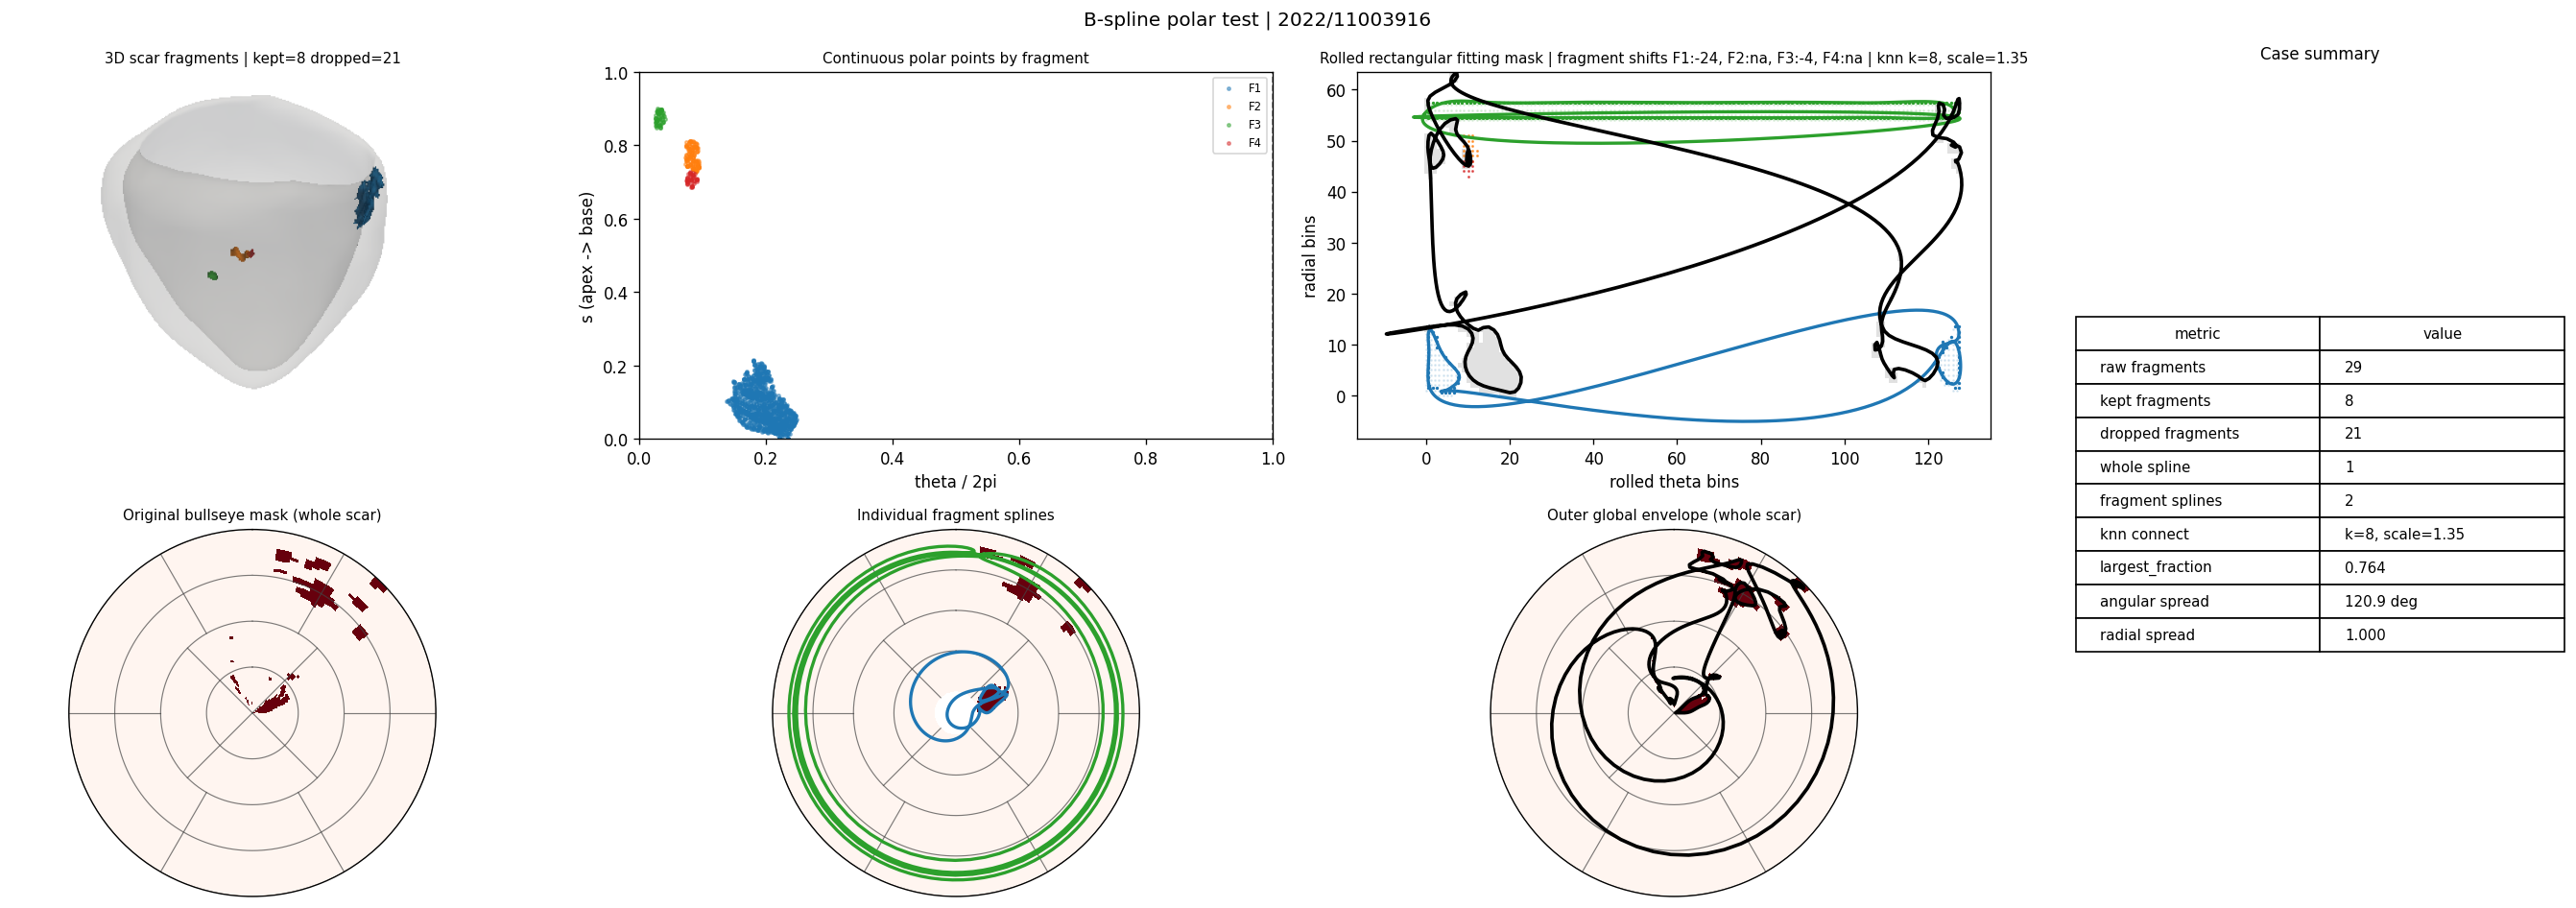

C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`,

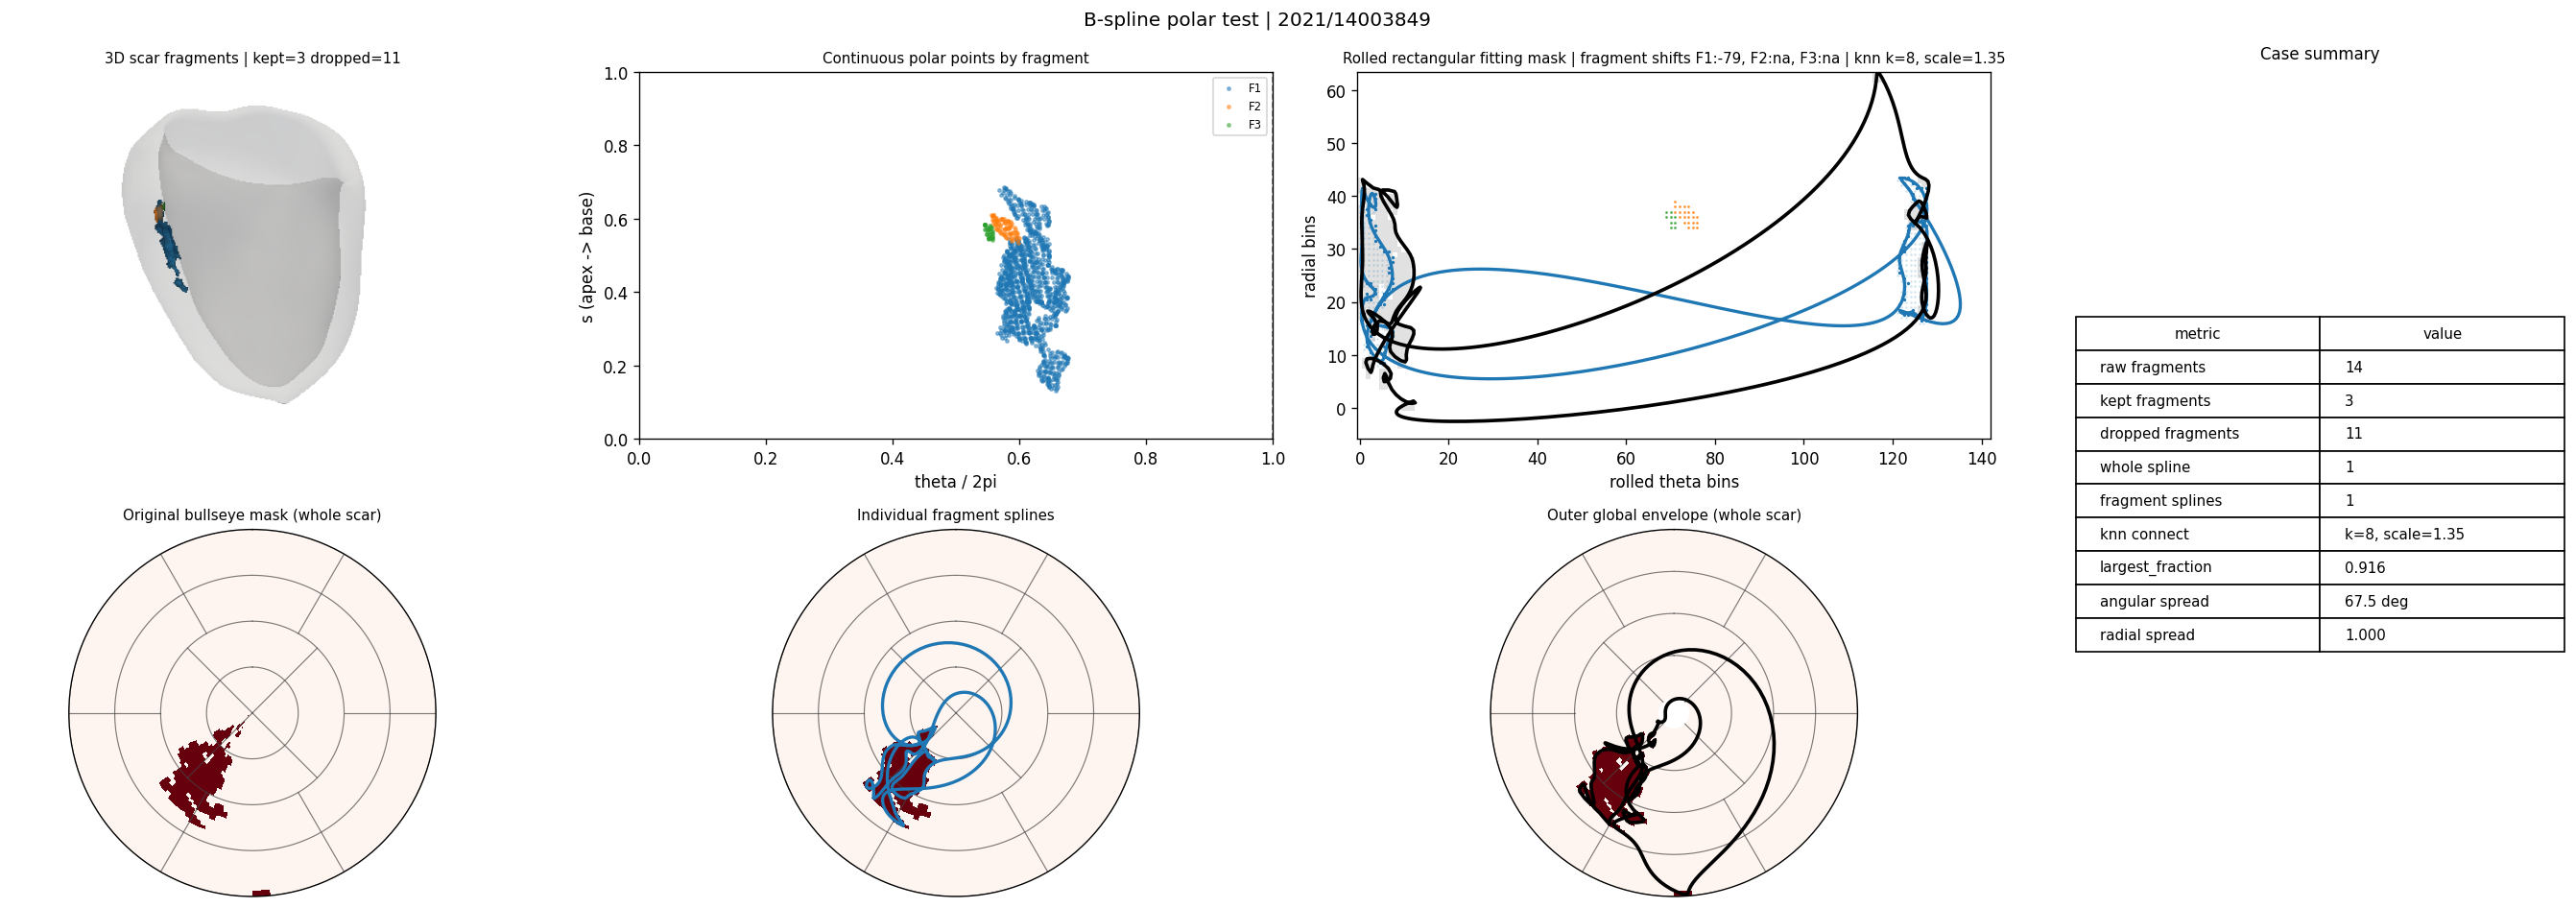

C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`,

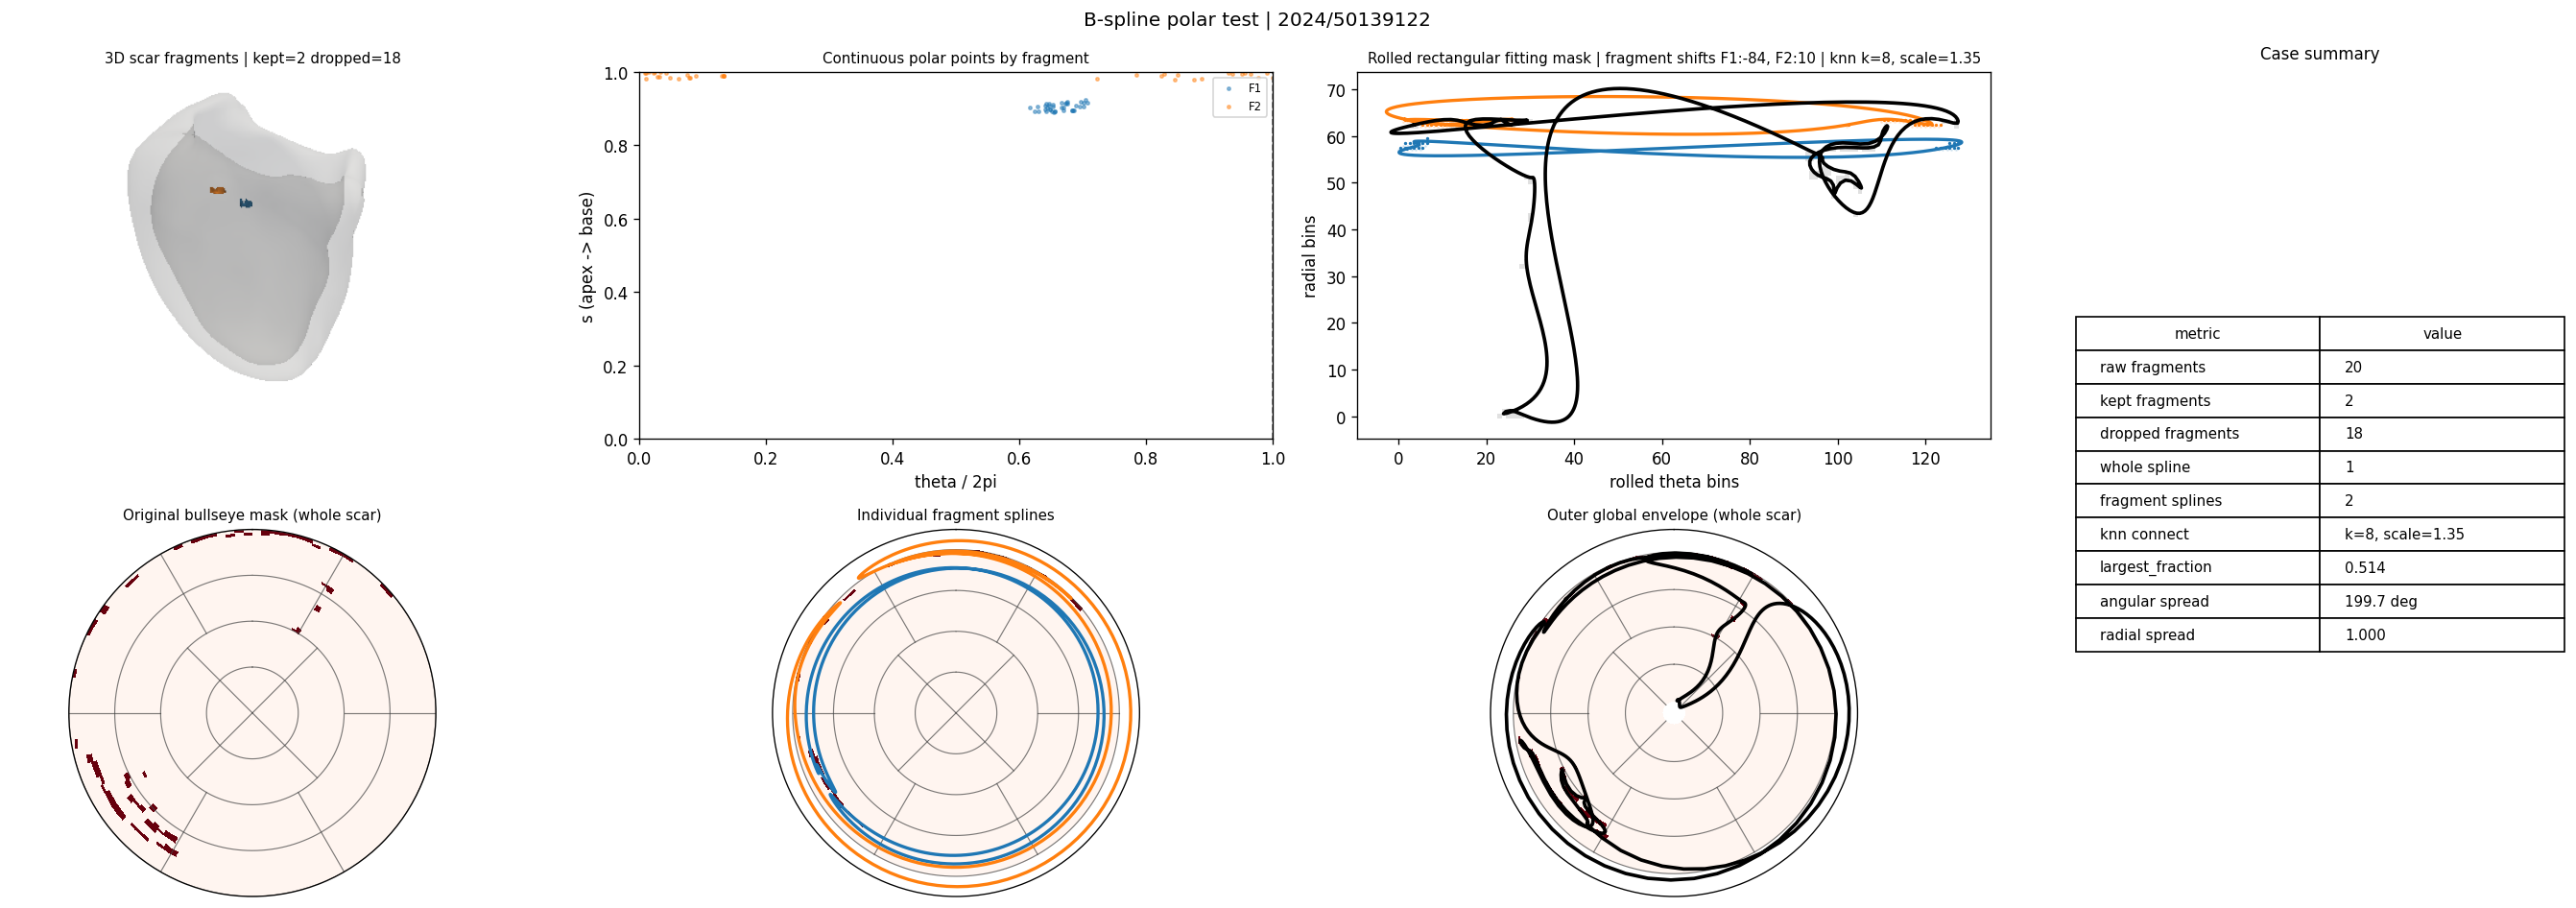

C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`,

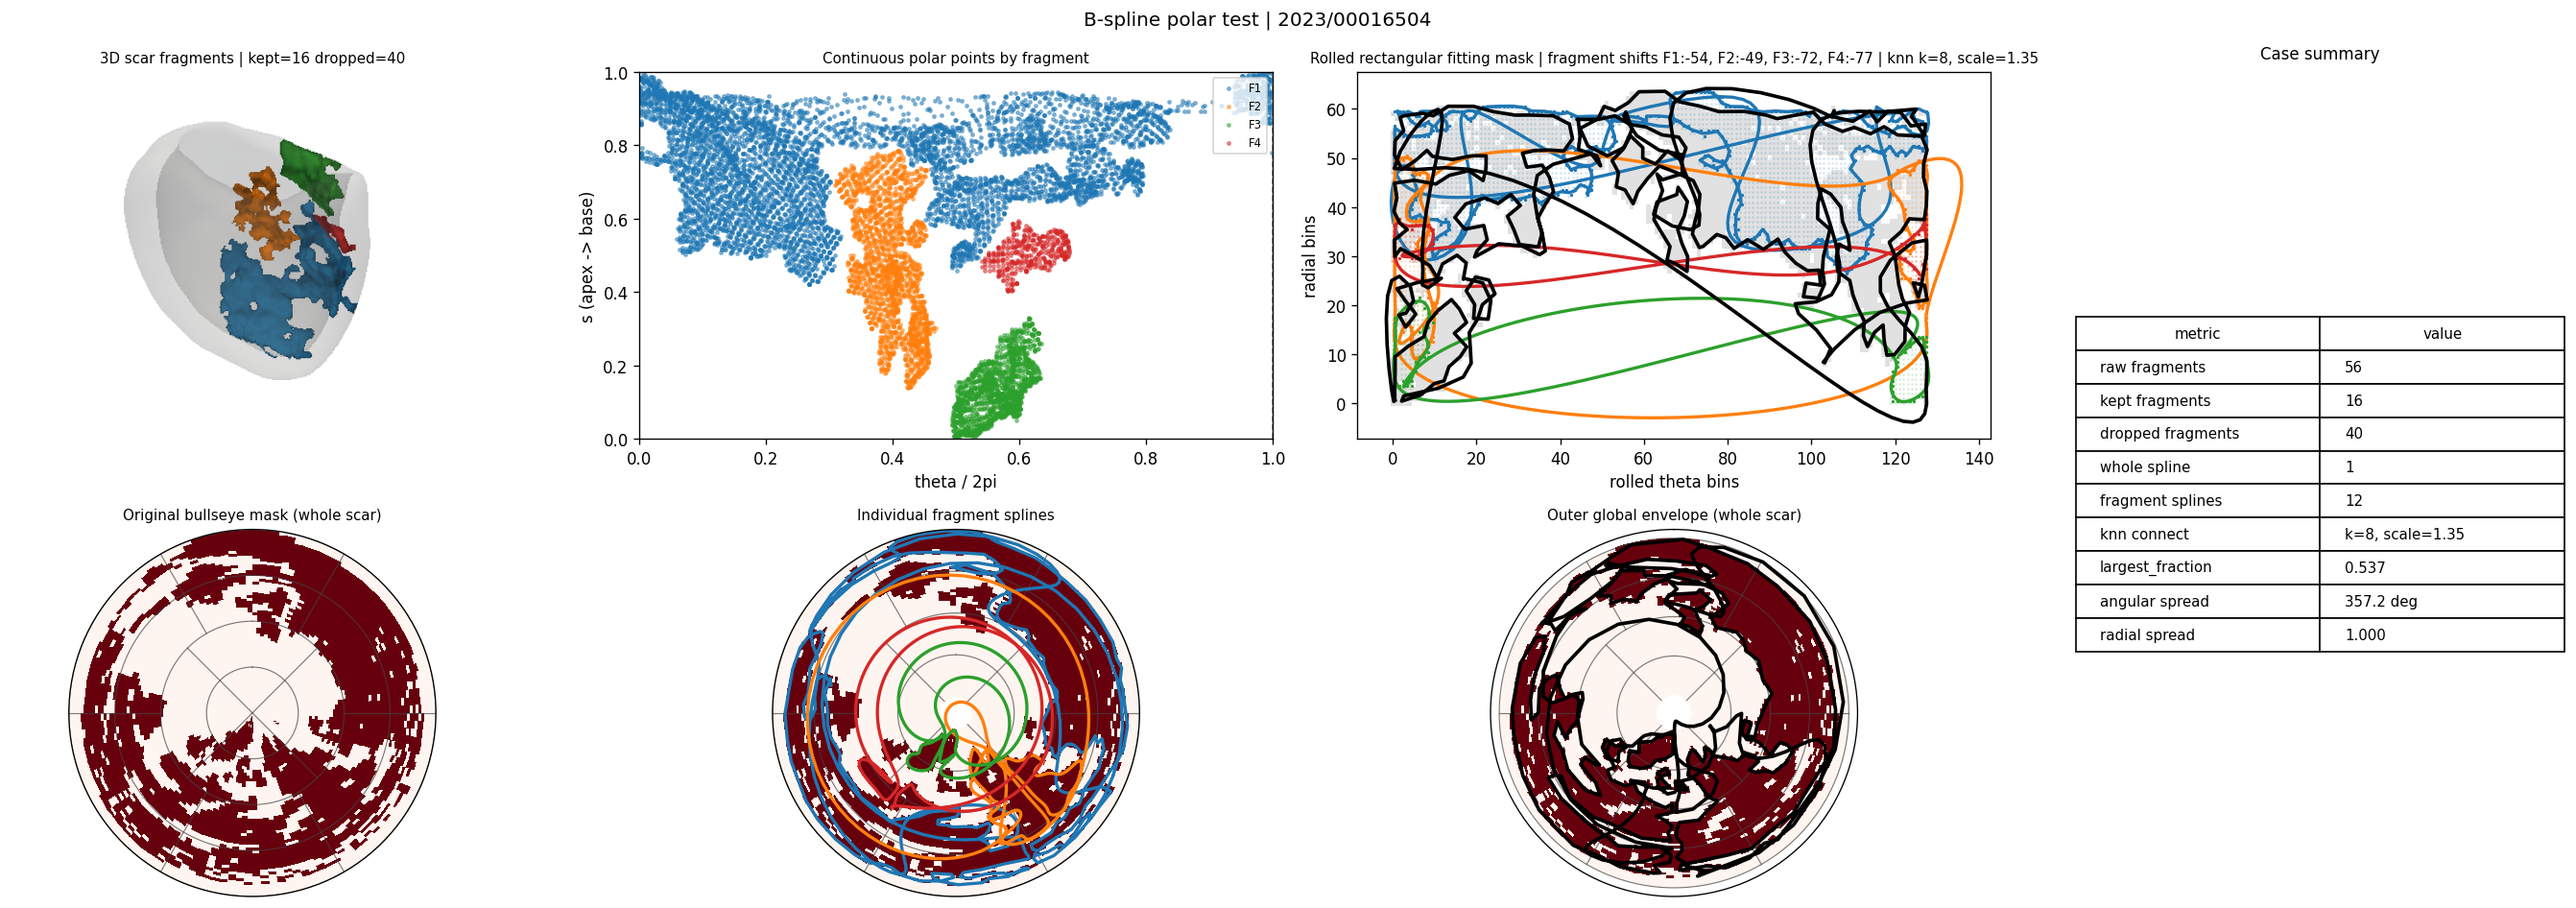

C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`,

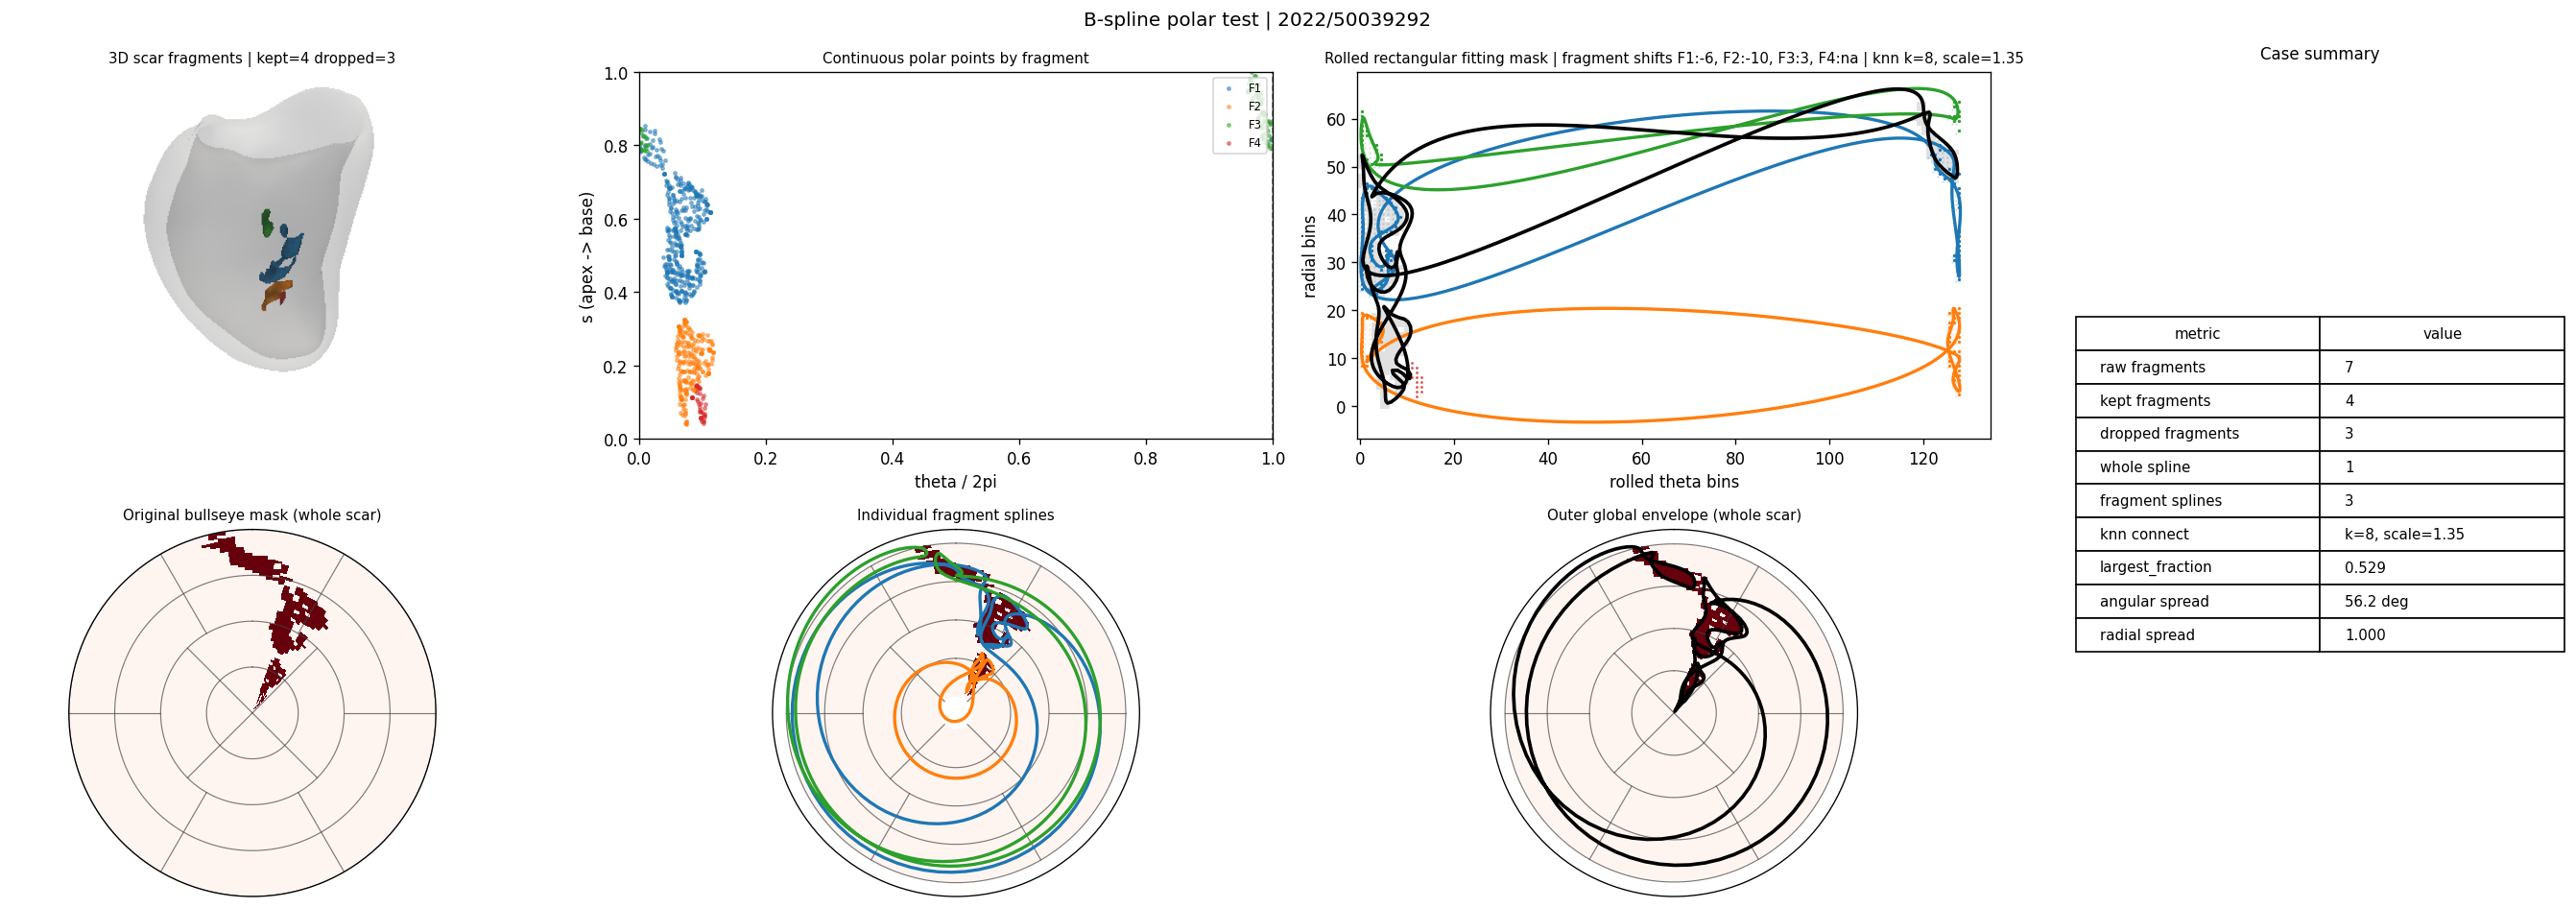

C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`,

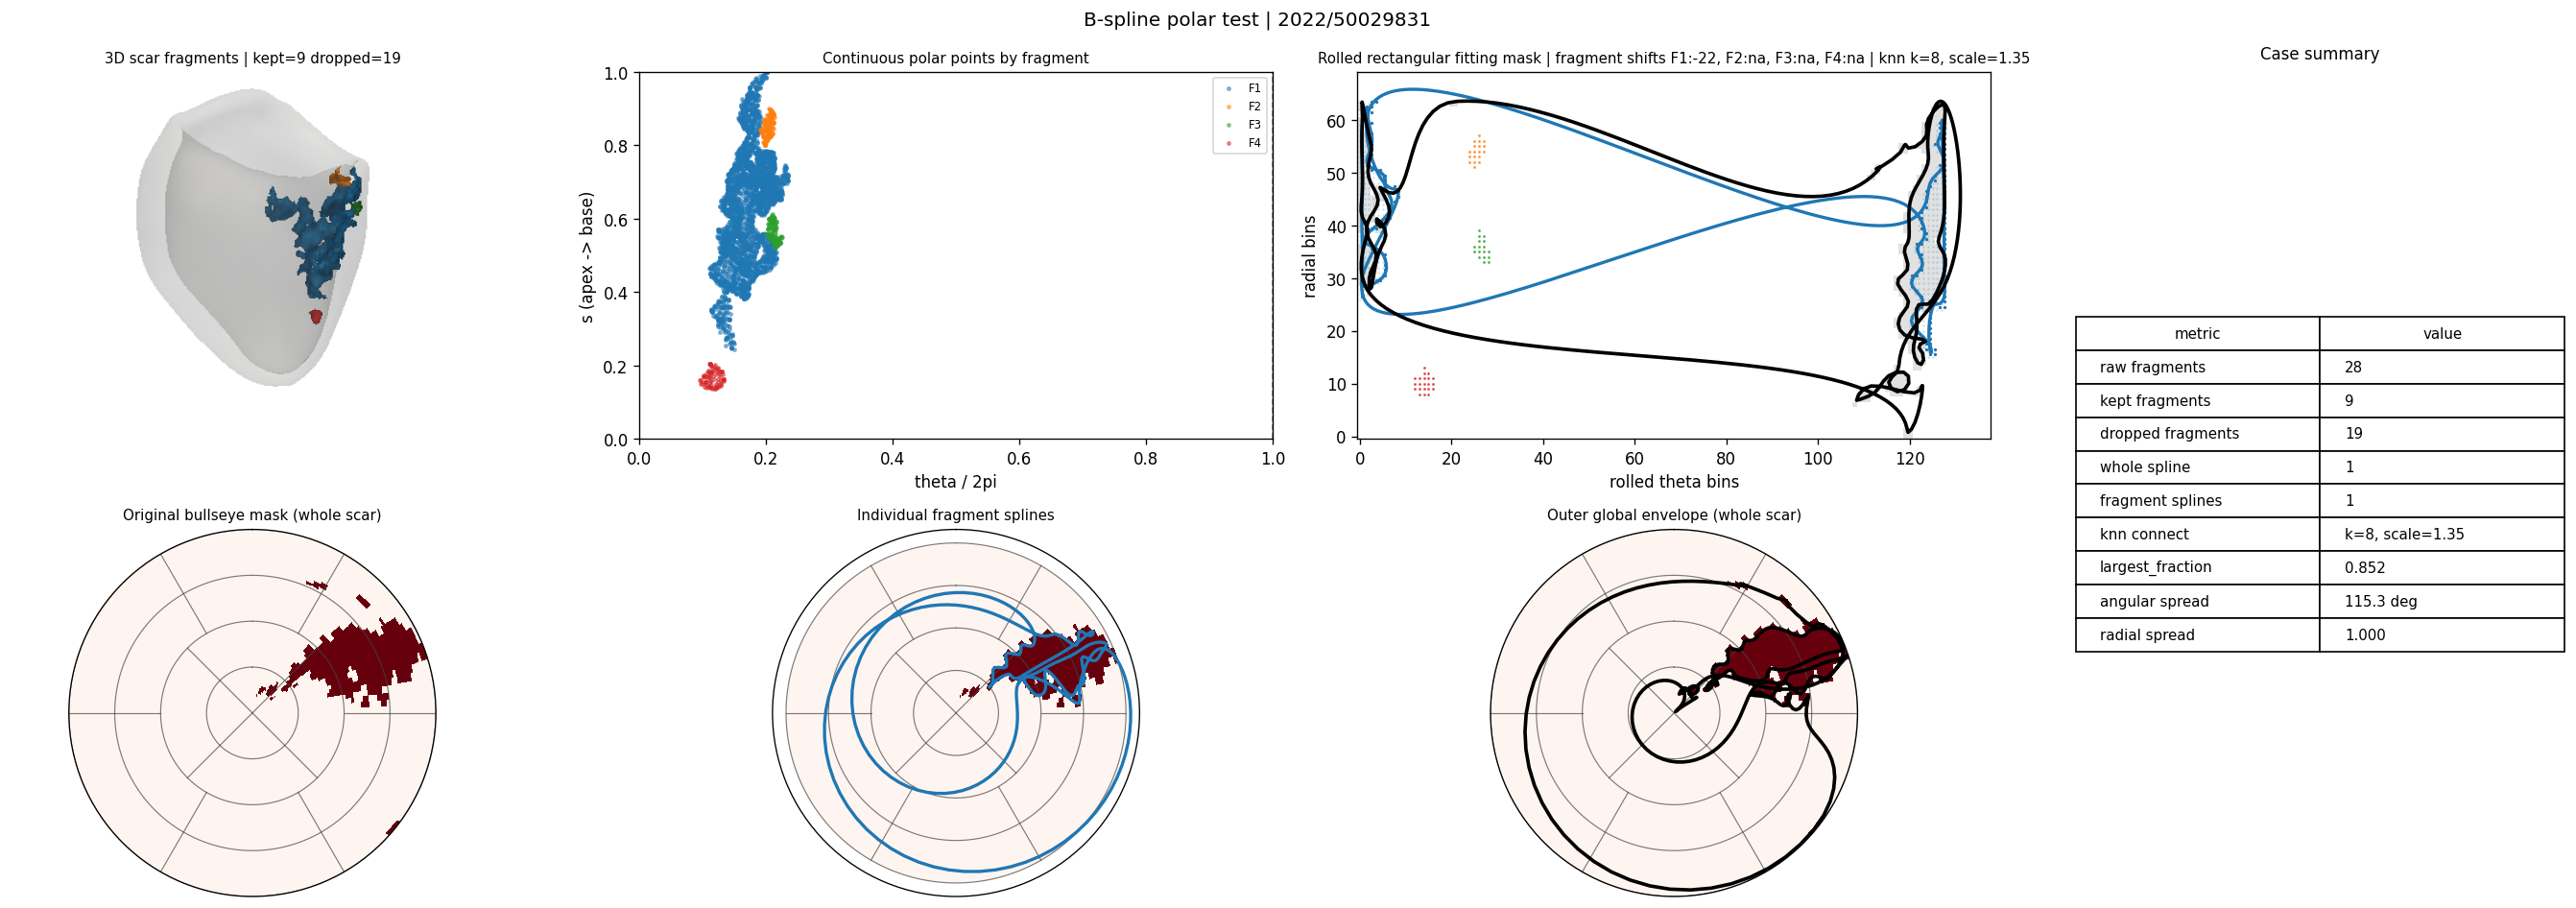

C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`,

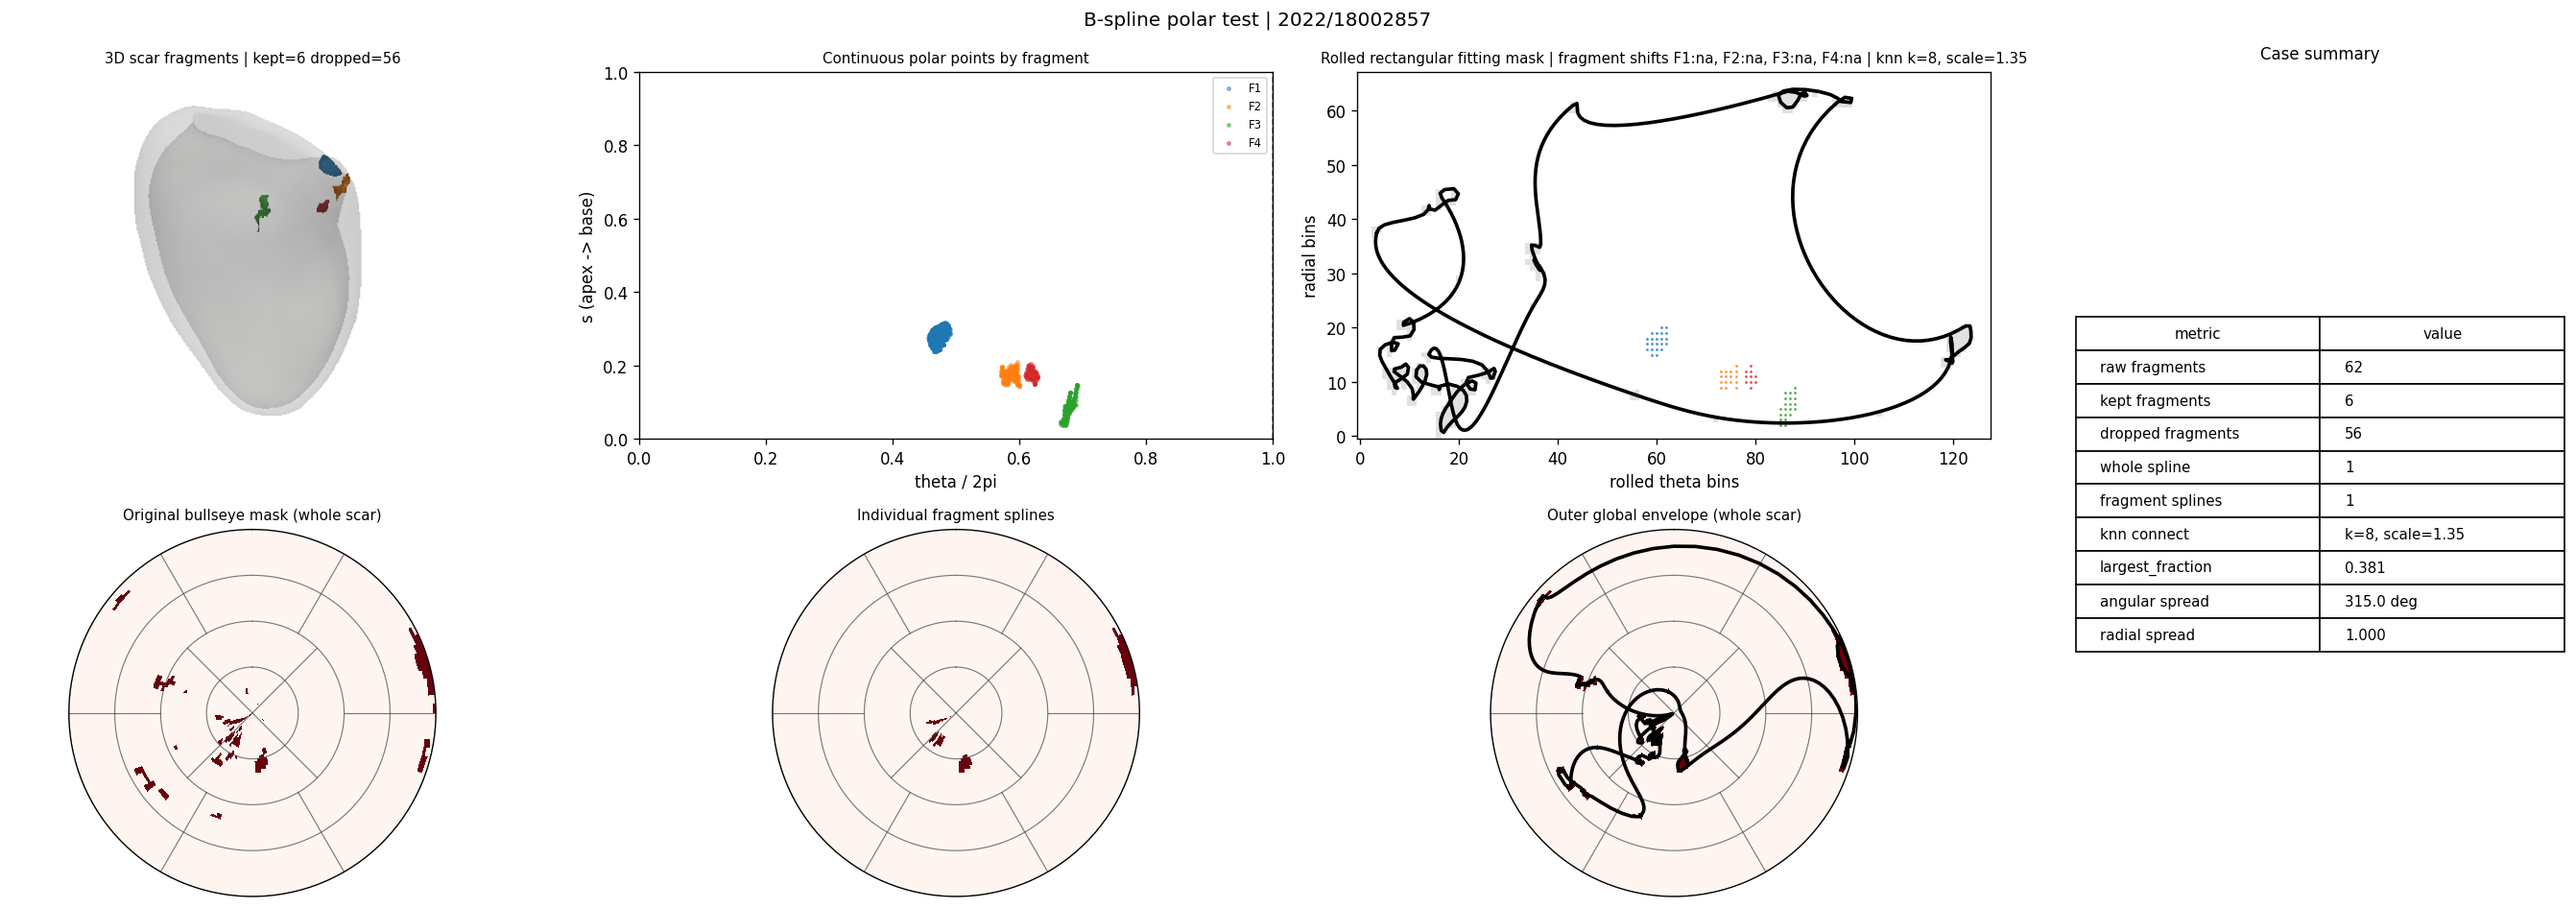

C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`,

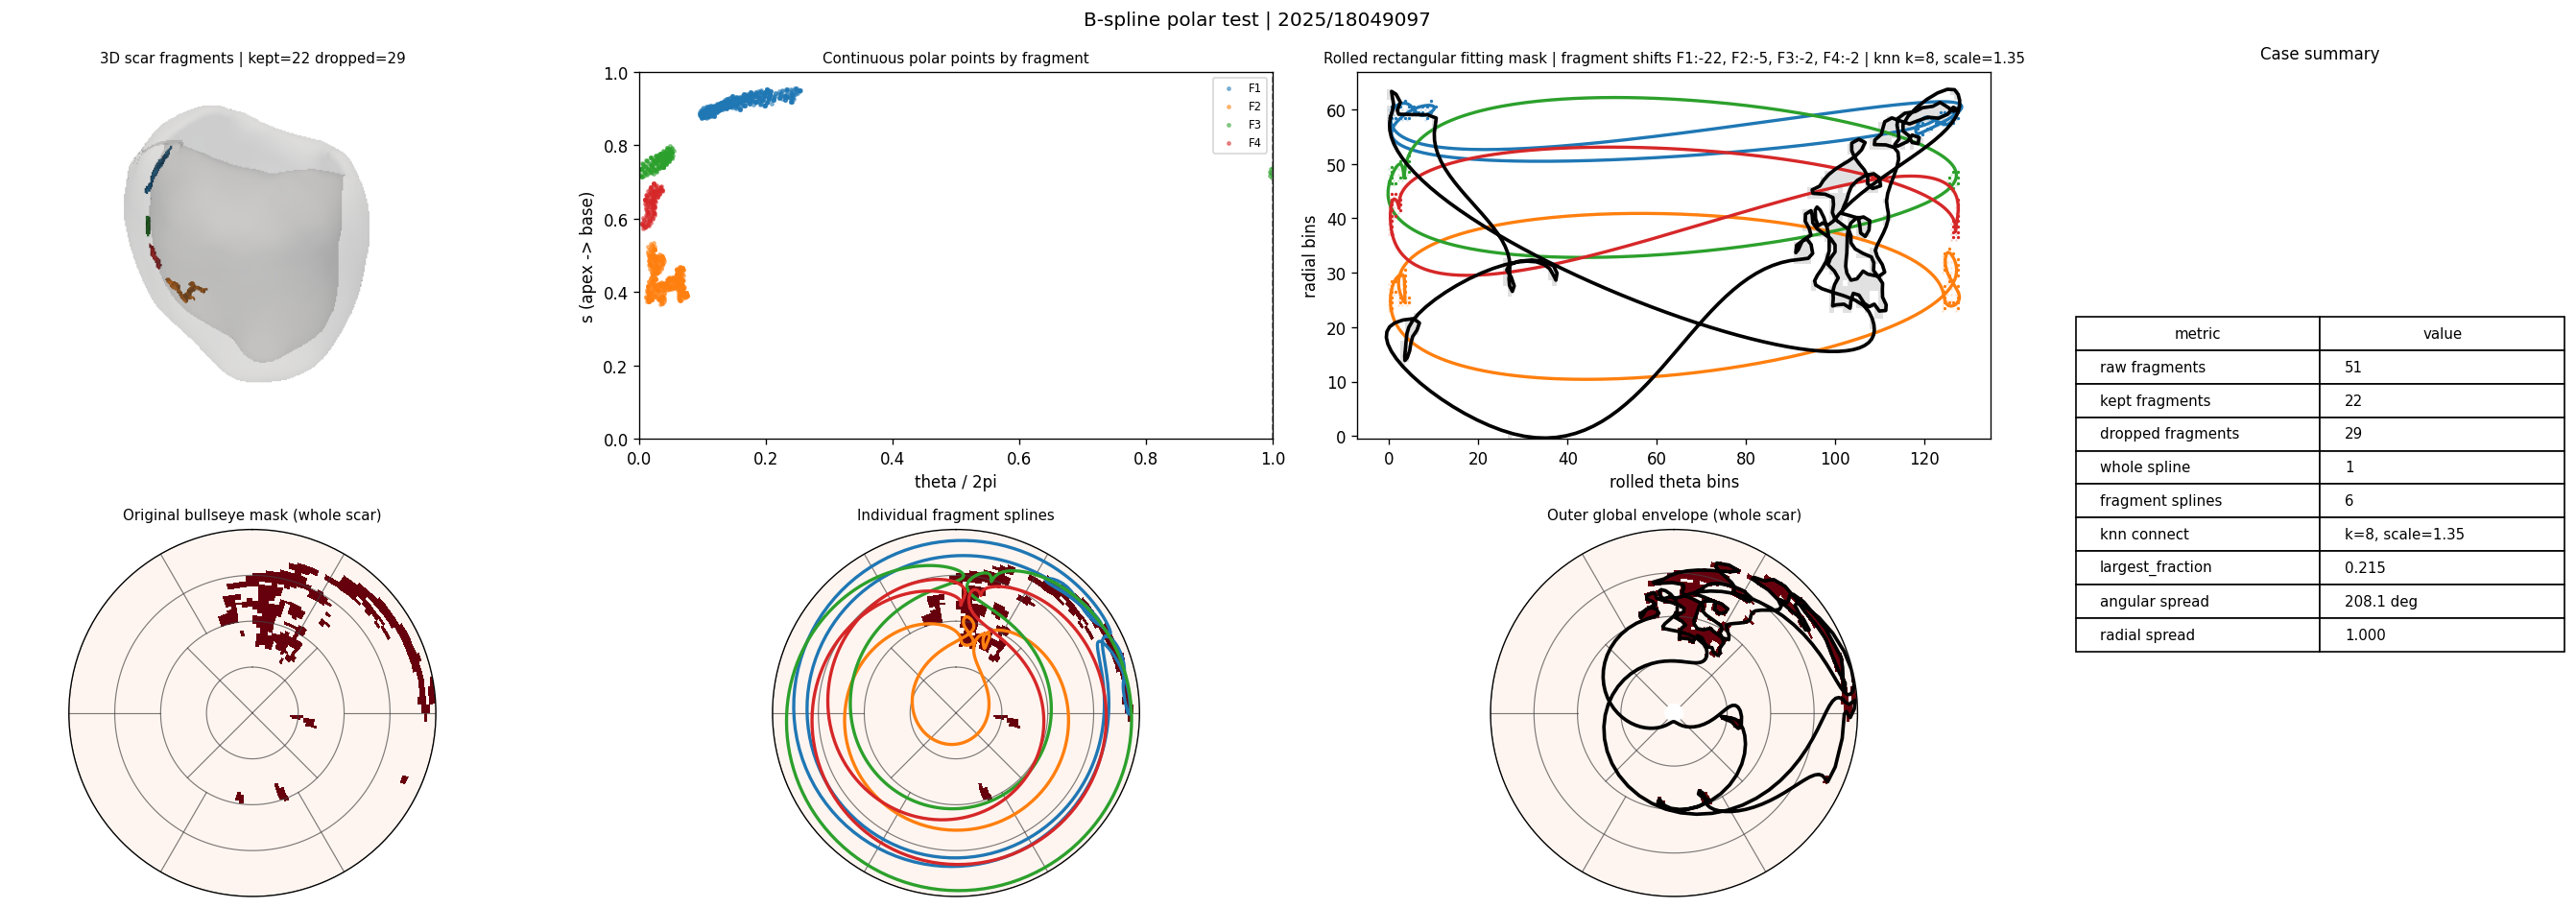

C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_12072\3098702760.py:28: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`,

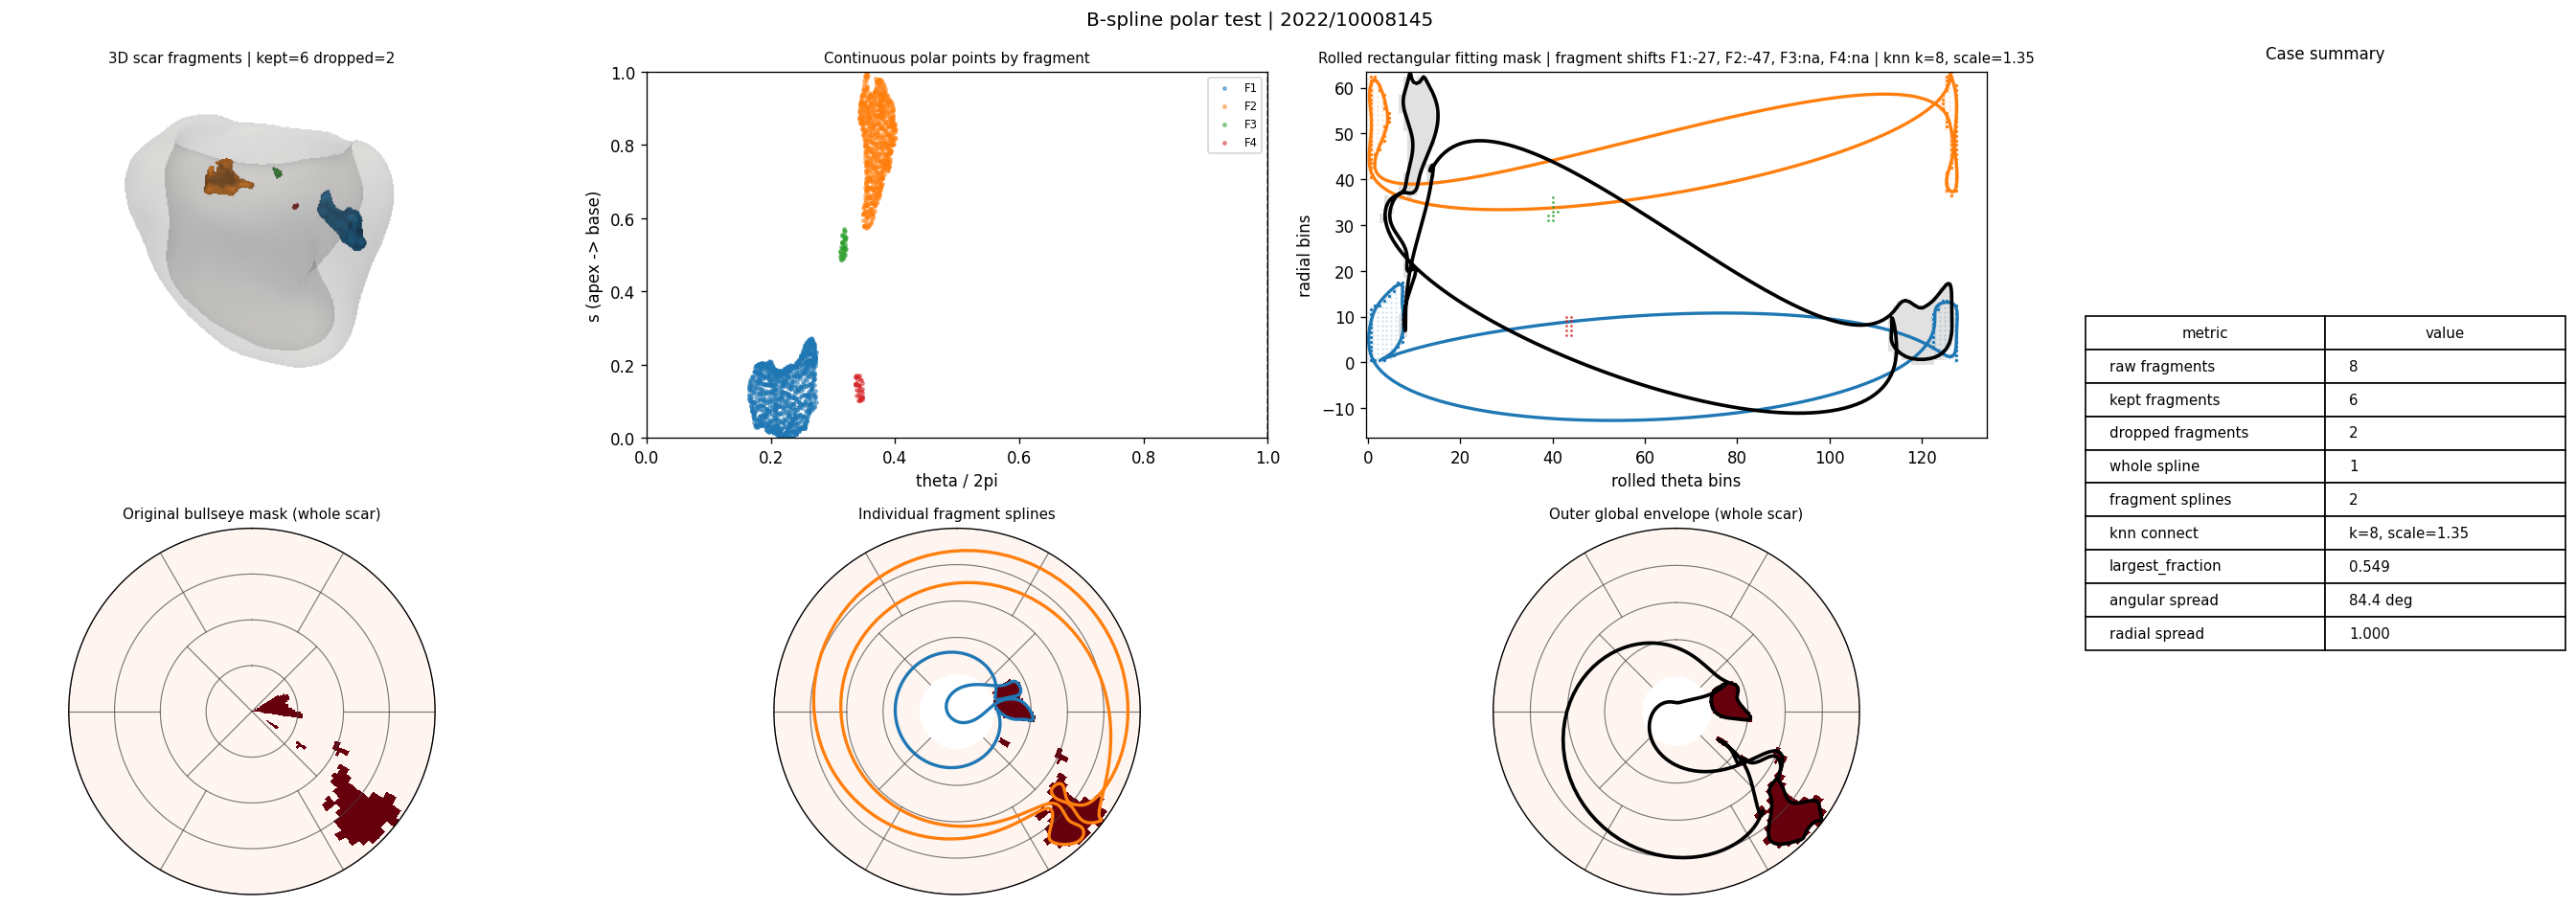

[{'key': '2024/20001226',
  'status': 'ok',
  'kept_fragments': 17,
  'fitted_splines': 3,
  'largest_fraction': 0.588,
  'angular_spread_deg': np.float64(126.6),
  'radial_spread': 1.0,
  'boundary_points': 158},
 {'key': '2022/11003916',
  'status': 'ok',
  'kept_fragments': 8,
  'fitted_splines': 2,
  'largest_fraction': 0.764,
  'angular_spread_deg': np.float64(120.9),
  'radial_spread': 1.0,
  'boundary_points': 320},
 {'key': '2021/14003849',
  'status': 'ok',
  'kept_fragments': 3,
  'fitted_splines': 1,
  'largest_fraction': 0.916,
  'angular_spread_deg': np.float64(67.5),
  'radial_spread': 1.0,
  'boundary_points': 143},
 {'key': '2024/50139122',
  'status': 'ok',
  'kept_fragments': 2,
  'fitted_splines': 2,
  'largest_fraction': 0.514,
  'angular_spread_deg': np.float64(199.7),
  'radial_spread': 1.0,
  'boundary_points': 82},
 {'key': '2023/00016504',
  'status': 'ok',
  'kept_fragments': 16,
  'fitted_splines': 12,
  'largest_fraction': 0.537,
  'angular_spread_deg': np.f

In [7]:
batch_keys = known_keys[:10]
batch_summary = []

for key in batch_keys:
    case = case_by_key[key]
    try:
        result = plot_bspline_case(case, save=False)
        total_boundary_pts = sum(len(fit["boundary_xy"]) for fit in result["fits"] if fit.get("fit_ok", False))
        fitted_splines = sum(1 for fit in result["fits"] if fit.get("fit_ok", False))
        batch_summary.append({"key": key, "status": "ok", "kept_fragments": result["kept_n_fragments"], "fitted_splines": fitted_splines, "largest_fraction": round(result["largest_fraction"], 3), "angular_spread_deg": round(result["angular_spread_deg"], 1), "radial_spread": round(result["radial_spread"], 3), "boundary_points": total_boundary_pts})
    except Exception as exc:
        print(f"Failed for {key}: {exc}")
        batch_summary.append({"key": key, "status": f"failed: {exc}", "kept_fragments": None, "boundary_points": None})

batch_summary

## Notes for interpretation

- If the spline follows the outer scar footprint consistently, it could become a compact shape descriptor before ISOMAP.
- If the spline collapses, self-intersects, or becomes very sensitive to seam placement, then the footprint is likely too fragmented or too non-single-valued in polar space.
- A natural next step would be to convert the spline to a fixed-length coefficient vector and compare those coefficients across patients, instead of comparing raw occupancy grids.

## Cone-based simple spline check

This is a simpler alternative to the mask-based fitting above.
It uses the full Core Zone mesh for one whole-scar spline, and connected components for fragment splines,
after projecting points into a cone-like embedding of the polar coordinates.

In [8]:
import importlib
import src.cone_bspline_simple as cone_bspline_simple

cone_bspline_simple = importlib.reload(cone_bspline_simple)
build_case_cone_splines = cone_bspline_simple.build_case_cone_splines
ALPHA_RADIUS_SCALE = getattr(cone_bspline_simple, "ALPHA_RADIUS_SCALE", 1.55)


def _cone_xy_to_theta_s(xy):
    xy = np.asarray(xy, dtype=float)
    theta = np.mod(np.arctan2(xy[:, 1], xy[:, 0]), 2.0 * np.pi)
    s = np.linalg.norm(xy, axis=1)
    return theta, s


def _plot_cone_bullseye(ax, whole, fragments, title):
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rticks([])
    ax.set_xticks([])
    theta = np.linspace(0.0, 2.0 * np.pi, 361)
    for radius in (0.25, 0.50, 0.75, 1.0):
        ax.plot(theta, np.full_like(theta, radius), color="#666666", lw=0.7, alpha=0.7)
    for item in (30, 90, 150, 210, 270, 330):
        th = np.deg2rad(item)
        ax.plot([th, th], [0.50, 1.0], color="#666666", lw=0.7, alpha=0.7)
    for item in (45, 135, 225, 315):
        th = np.deg2rad(item)
        ax.plot([th, th], [0.0, 0.50], color="#666666", lw=0.7, alpha=0.7)
    t_whole, s_whole = _cone_xy_to_theta_s(whole.xy)
    ax.scatter(t_whole, s_whole, s=2.5, alpha=0.10, color="firebrick", zorder=1)
    if whole.spline_xy is not None:
        t_spl, s_spl = _cone_xy_to_theta_s(whole.spline_xy)
        ax.plot(t_spl, s_spl, color="black", lw=3.6, zorder=6)
    for idx, frag in enumerate(fragments):
        color = FRAG_COLORS[idx % len(FRAG_COLORS)]
        t_frag, s_frag = _cone_xy_to_theta_s(frag.xy)
        ax.scatter(t_frag, s_frag, s=2.2, alpha=0.10, color=color, zorder=1)
        if frag.spline_xy is not None:
            t_spl, s_spl = _cone_xy_to_theta_s(frag.spline_xy)
            ax.plot(t_spl, s_spl, color=color, lw=2.8, zorder=6)
    ax.set_title(title, fontsize=9)


def plot_cone_spline_case(case, min_fragment_points=MIN_VERTS_FRAGMENT, alpha_radius_scale=ALPHA_RADIUS_SCALE):
    result = build_case_cone_splines(case, min_fragment_points=min_fragment_points, alpha_radius_scale=alpha_radius_scale)

    fig = plt.figure(figsize=(18, 8))
    gs = fig.add_gridspec(2, 4, width_ratios=[1.0, 1.0, 1.0, 0.9], height_ratios=[1.0, 1.0])
    fig.suptitle(f"Cone-based spline check | {result.key}", fontsize=12)

    ax = fig.add_subplot(gs[0, 0])
    ax.scatter(result.whole.xy[:, 0], result.whole.xy[:, 1], s=3, alpha=0.14, color="firebrick", label="whole points", zorder=1)
    if result.whole.hull_xy is not None:
        hull = np.vstack([result.whole.hull_xy, result.whole.hull_xy[0]])
        ax.plot(hull[:, 0], hull[:, 1], color="black", lw=1.2, ls="--", label="whole hull", zorder=2)
    if result.whole.spline_xy is not None:
        ax.plot(result.whole.spline_xy[:, 0], result.whole.spline_xy[:, 1], color="royalblue", lw=4.0, label="whole spline", zorder=6)
    ax.set_title(f"Whole scar | fit={result.whole.fit_ok}", fontsize=9)
    ax.set_aspect("equal")
    ax.legend(fontsize=7)

    ax = fig.add_subplot(gs[0, 1])
    if result.whole.hull_xy is not None:
        hull = np.vstack([result.whole.hull_xy, result.whole.hull_xy[0]])
        ax.plot(hull[:, 0], hull[:, 1], color="black", lw=1.4, ls="--", label="whole hull", zorder=2)
    if result.whole.spline_xy is not None:
        ax.plot(result.whole.spline_xy[:, 0], result.whole.spline_xy[:, 1], color="deepskyblue", lw=4.2, label="whole spline", zorder=6)
    ax.set_title("Whole hull + spline only", fontsize=9)
    ax.set_aspect("equal")
    ax.legend(fontsize=7)

    ax = fig.add_subplot(gs[0, 2])
    for idx, frag in enumerate(result.fragments):
        color = FRAG_COLORS[idx % len(FRAG_COLORS)]
        ax.scatter(frag.xy[:, 0], frag.xy[:, 1], s=3, alpha=0.14, color=color, zorder=1)
        if frag.hull_xy is not None:
            hull = np.vstack([frag.hull_xy, frag.hull_xy[0]])
            ax.plot(hull[:, 0], hull[:, 1], color=color, lw=1.1, ls="--", zorder=2)
        if frag.spline_xy is not None:
            ax.plot(frag.spline_xy[:, 0], frag.spline_xy[:, 1], color=color, lw=3.2, zorder=6)
    ax.set_title(f"Fragments | kept={result.kept_n_fragments} dropped={result.dropped_fragments}", fontsize=9)
    ax.set_aspect("equal")

    ax = fig.add_subplot(gs[1, 0], projection="polar")
    _plot_cone_bullseye(ax, result.whole, [], "Cone whole spline on bullseye")

    ax = fig.add_subplot(gs[1, 1], projection="polar")
    _plot_cone_bullseye(ax, result.whole, result.fragments, "Cone whole + fragment splines on bullseye")

    ax = fig.add_subplot(gs[:, 3])
    ax.axis("off")
    lines = [
        f"key: {result.key}",
        f"raw fragments: {result.raw_n_fragments}",
        f"kept fragments: {result.kept_n_fragments}",
        f"dropped fragments: {result.dropped_fragments}",
        f"largest_fraction: {result.largest_fraction:.3f}",
        f"alpha_radius_scale: {alpha_radius_scale}",
        f"whole fit ok: {result.whole.fit_ok}",
        f"fragment fits ok: {sum(int(f.fit_ok) for f in result.fragments)} / {len(result.fragments)}",
    ]
    if result.whole.fit_error:
        lines.append(f"whole fit error: {result.whole.fit_error}")
    ax.text(0.0, 1.0, "\n".join(lines), va="top", fontsize=9, family="monospace")

    plt.tight_layout()
    plt.show()
    return result

C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\src\cone_bspline_simple.py:68: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\src\cone_bspline_simple.py:68: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\src\cone_bspline_simple.py:68: PyVistaFutureWarning: The default value of `algorithm`

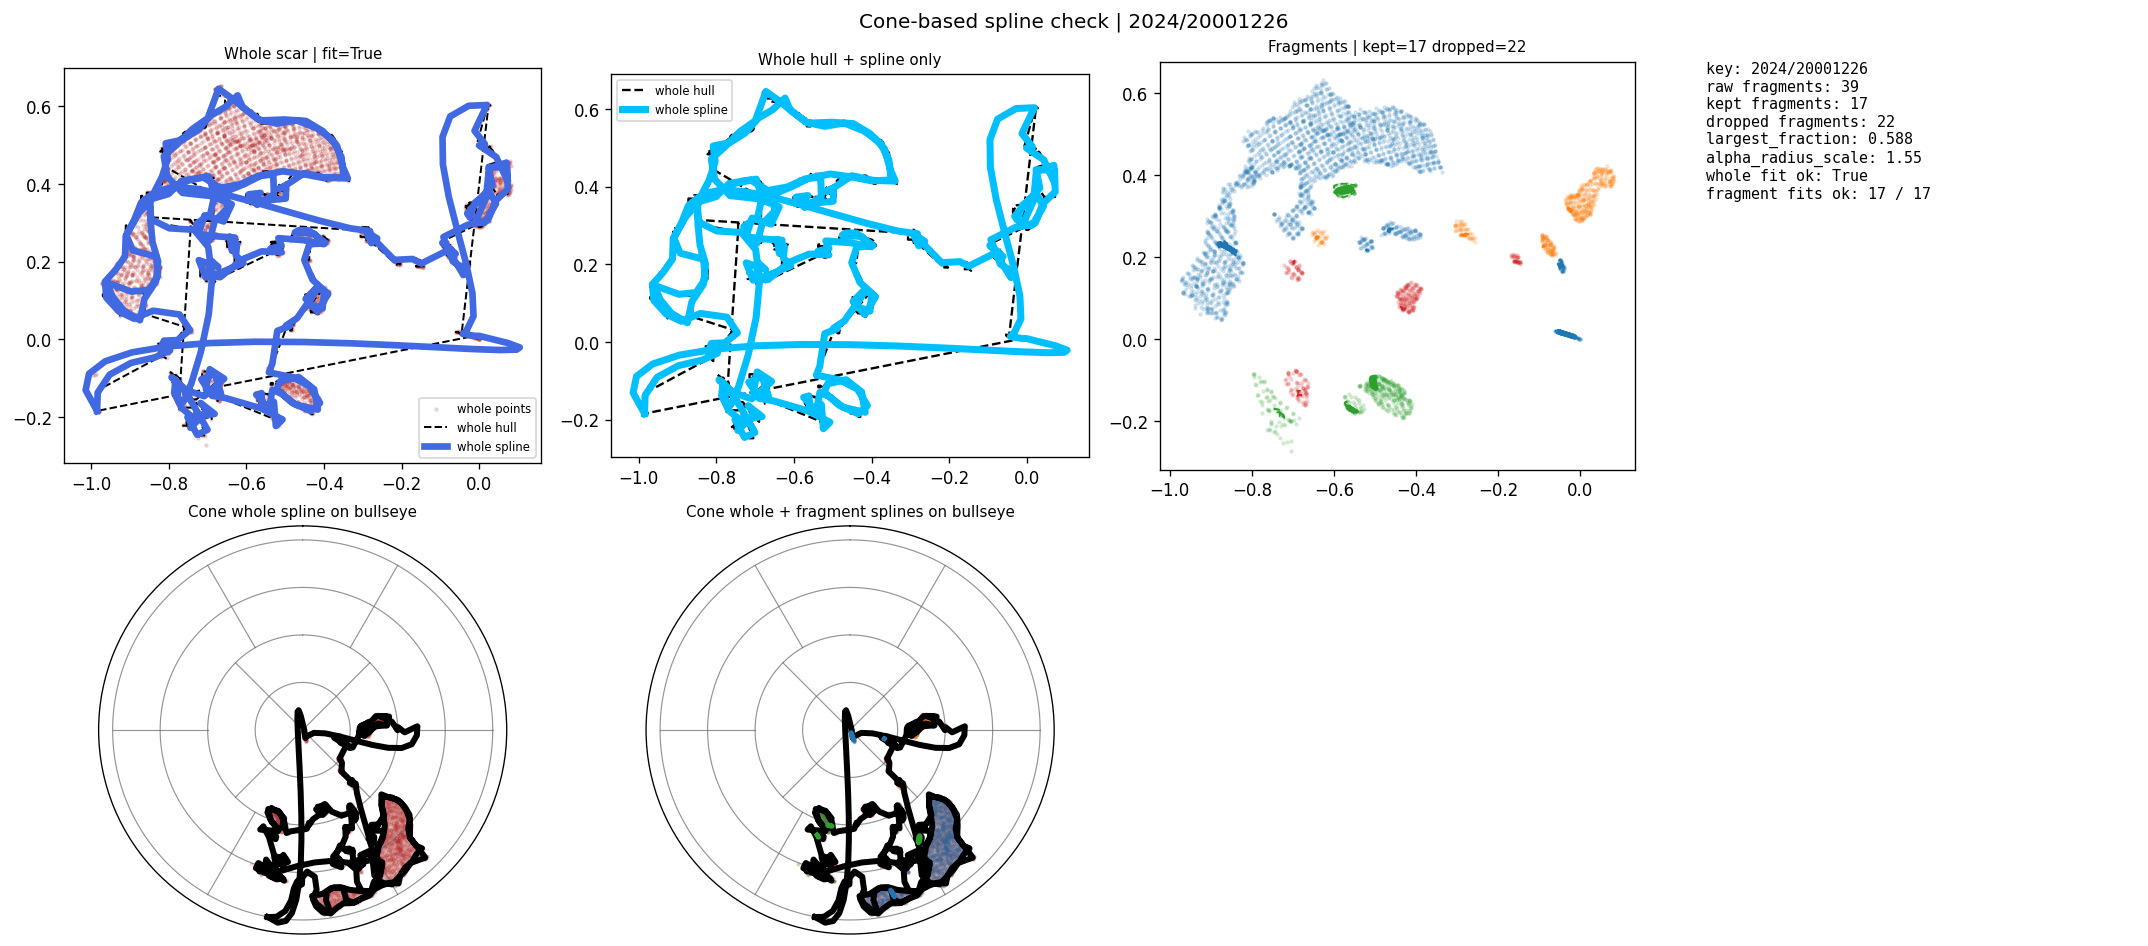

In [9]:
test_key = known_keys[0]
test_case = case_by_key[test_key]

cone_case_result = plot_cone_spline_case(test_case)